In [1]:
!python --version
import os
import warnings

#suppress warnings
warnings.filterwarnings('ignore')

Python 3.10.20


# Python libraries

In [2]:
import pandas as pd
import numpy as np
np.random.seed(42) ## for reproducibility --- this is important for the random number generation in the Bayesian model
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
from scipy.optimize import curve_fit
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import numpy as np
import pandas as pd


import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.patches import Circle


import cartopy.crs as ccrs
import cmocean.cm as cmo

try:
    import proplot as plot
except ImportError:
    plot = None  # proplot is optional; install via: pip install proplot==0.9.7
import seaborn as sns
from shapely.geometry import Point, Polygon

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from ipywidgets import FloatRangeSlider, VBox
from IPython.display import display


from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time
from pathlib import Path


from cmdstanpy import CmdStanModel



# (Re)load your package
import TEXAS
# 1) Grab the low‐level functions you need
%load_ext autoreload
%autoreload 2
from TEXAS.stan.compiler import StanCompiler
from TEXAS.stan.sampler  import StanSampler
from TEXAS.stan.sampler import get_posterior, save_posterior
from TEXAS.stan.io import load_posterior
from TEXAS import predict_T_from_RI, predict_RI_from_T
from TEXAS.ensemble import generate_ensemble_auto
from TEXAS.data import MahalanobisOutlierDetector
from TEXAS.plotting import *

import TEXAS
print(TEXAS.__version__)  

import importlib

import bayspline as bsl
import bayspar as bsr

from functools import partial

0.1.2


# Cosmetic settings

In [3]:
datatype_color_dict = {
    'coretop':'cyan9',
    'culture':'yellow9',
    'mesocosm':'pink9',
    'culmeso':'violet9',
    'culmesocore':'gray9',
}

datatype_marker_dict = {
    'culture':'^',
    'mesocosm':'s',
    'coretop':'.',
}

datatype2_color_dict = {
    'coretop_high23ratio':'cyan9',
    'coretop_low23ratio':'cyan3',
    'culture':'yellow9',
    'mesocosm':'pink9',
    'culmeso':'violet9',
    'culmesocore':'gray9',
}

period_color_dict = {
    'Quaternary':'#f8f987',
    'Neogene':'#f7e73d',
    'Paleogene':'#e59c59',
    'Cretaceous':'#96c657',
    'Jurassic':'#6db1c7'
}

def label_pvalues(x):
    if x<0.001:
        return r'$\it{P}$<.001'
    elif x<0.01:
        return r'$\it{P}$<.01'
    elif x<0.05:
        return r'$\it{P}$<.05'
    elif x<0.1:
        return r'$\it{P}$<.1'
    elif x>=0.1:
        return r'$\it{P}$>.1'

# Miscellaneous functions

In [4]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,loN_meso = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(loN_meso,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    loN_cul, lat1 = origin
    loN_meso, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(loN_meso - loN_cul)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.ataN_meso(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient


import inspect
from IPython.display import Markdown
def display_function_signature(func):
    sig = inspect.signature(func)
    params = []
    for param_name, param in sig.parameters.items():
        if param.default != inspect.Parameter.empty:
            params.append(f"    {param_name}={param.default}")
        else:
            params.append(f"    {param_name}")

    formatted = f"{func.__name__}(\n" + ",\n".join(params) + "\n)"
    return Markdown(f"```python\n{formatted}\n```")

In [5]:
def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(66.6667,-18.6667),
        'schouten03':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien17':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:

    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(0.015,0.280),
        'schouten03':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrien17':(0.021,0.105), #(0.021,0.105)  <--- recalculated from the Fig S2 in O'Brien et al., 2017 | (0.0170,0.19) <--- shown in the main text of O'Brien et al., 2017
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

## Logistic equations

In [6]:
def logistic(x, x0, k, L, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

def logistic_fixed_upper(x, x0, k, b):
    return (1-b) / (1 + np.exp(-k * (x - x0))) + b

def inverse_logistic_fixed_upper(y, x0, k, b):
    return x0 + (np.log((1 - b)/y - 1) / -k)


def generalized_logistic_model(x, x0, a, b, k, v, Q):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    - Q: Exponent
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((a - b) / np.power(1 + Q * np.exp(-k * (x - x0)), 1/v))
    return Y

def generalized_logistic_model_fixed_upper(x, x0, b, k, v, Q):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    - Q: Exponent
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((1 - b) / np.power(1 + Q * np.exp(-k * (x - x0)), 1/v))
    return Y

def inverse_generalized_logistic_model_fixed_upper(y, x0, b, k, v, Q):
    """
    Inverse of the generalized logistic model function with a fixed upper asymptote.

    Parameters:
    - y: The output value for which to compute the inverse.
    - x0: Inflection point
    - b: Lower asymptote (left asymptote)
    - k: Slope
    - v: Shape parameter
    - Q: Exponent
    Returns:
    - The input value x corresponding to the output y in the generalized logistic model.
    """
    
    term = ((1 - b) / (y - b))**v - 1
    x = x0 + (np.log(Q / term) / k)
    
    return x

In [7]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

# Set local path

In [8]:
from pathlib import Path
from cmdstanpy import set_cmdstan_path, cmdstan_path
from TEXAS.utils.paths import CMDSTAN_DIR

set_cmdstan_path(str(CMDSTAN_DIR))
print("Set CMDSTAN ->", cmdstan_path())

# Detect environment
IN_DOCKER = Path("/home/micromamba/app").exists()

if IN_DOCKER:
    local_onedrive_path = Path("/mnt/onedrive")
    local_github_path = Path("/home/micromamba/app")
    print(local_github_path)
else:
    local_onedrive_path = Path.home() / "OneDrive"   # adjust if needed
    local_github_path = Path.home() / "Documents/GitHub/TEXAS"
    print(local_github_path)

Set CMDSTAN -> /opt/cmdstan/cmdstan-2.36.0
/home/micromamba/app


# PhanTEX Analysis

In [10]:
# Paleo-data plotting
fpath = fr'{local_github_path}/data/spreadsheets'
fname = 'ols_tex_thermoT_thisStudy.pkl'

import pickle

with open(os.path.join(fpath,fname), 'rb') as f:
    ols_tex_thermoT = pickle.load(f)
    
slope = ols_tex_thermoT.coef_[0]
intercept = ols_tex_thermoT.intercept_

fpath = fr'{local_github_path}/data/spreadsheets/published_data'
fname = 'PhanSST_v001_extendedRR_121025.csv'
PhanSST_df = pd.read_csv(os.path.join(fpath,fname))
PhanSST_df['pubYear'] = PhanSST_df['LeadAuthor'] + PhanSST_df['Year'].astype(str)

PhanAlk_df = PhanSST_df[PhanSST_df['ProxyType']=='uk'].reset_index(drop=True)
PhanAlk_df = PhanAlk_df.rename(columns={'ProxyValue':'Uk37'})
PhanAlk_df

,SampleID,SiteName,SiteHole,MBSF,MCD,SampleDepth,Formation,Country,ContinentOcean,ModLat,...,Cren,Crenisomer,BIT,dRI,MI,LeadAuthor,Year,PublicationDOI,DataDOI,pubYear
0,NaN,DEQ161-592,NaN,19.13,NaN,NaN,Yorktown,United States of America,na,36.680,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
1,NaN,DEQ161-592,NaN,20.56,NaN,NaN,Yorktown,United States of America,na,36.680,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
2,NaN,DEQ161-592,NaN,20.97,NaN,NaN,Yorktown,United States of America,na,36.680,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
3,NaN,DEQ161-592,NaN,21.78,NaN,NaN,Yorktown,United States of America,na,36.680,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
4,NaN,DEQ161-592,NaN,22.09,NaN,NaN,Yorktown,United States of America,na,36.680,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,Dowsett2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35703,NaN,U1510,NaN,3.95,NaN,3.95,NaN,NaN,pa,-36.329,...,NaN,NaN,NaN,NaN,NaN,Rattanasriampaipong,2025,NaN,NaN,Rattanasriampaipong2025
35704,NaN,U1510,NaN,3.99,NaN,3.99,NaN,NaN,pa,-36.329,...,NaN,NaN,NaN,NaN,NaN,Rattanasriampaipong,2025,NaN,NaN,Rattanasriampaipong2025
35705,NaN,U1510,NaN,4.19,NaN,4.19,NaN,NaN,pa,-36.329,...,NaN,NaN,NaN,NaN,NaN,Rattanasriampaipong,2025,NaN,NaN,Rattanasriampaipong2025
35706,NaN,U1510,NaN,4.34,NaN,4.34,NaN,NaN,pa,-36.329,...,NaN,NaN,NaN,NaN,NaN,Rattanasriampaipong,2025,NaN,NaN,Rattanasriampaipong2025


In [11]:
# PhanTEX_df = PhanSST_df[PhanSST_df['ProxyType']=='tex'].reset_index(drop=True)
# PhanTEX_df = PhanTEX_df.rename(columns={'ProxyValue':'TEX86',
#                                         'GDGT0':'fGDGT_0',
#                                         'GDGT1':'fGDGT_1',
#                                         'GDGT2':'fGDGT_2',
#                                         'GDGT3':'fGDGT_3',
#                                         'Cren':'fGDGT_cren',
#                                         'Crenisomer':'fGDGT_cren_prime'})
# PhanTEX_df = PhanTEX_df.dropna(subset=['fGDGT_0','fGDGT_1','fGDGT_2','fGDGT_3','fGDGT_cren','fGDGT_cren_prime']).reset_index(drop=True)
# PhanTEX_df['SampleID'] = [f'PhanTEX_RR{i:04d}' for i in range(len(PhanTEX_df))]

# features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
# sum_allGDGTs = PhanTEX_df[features].sum(axis=1)
# for feat in features:
#     PhanTEX_df[feat] = PhanTEX_df[feat] / sum_allGDGTs
# PhanTEX_df['ringIndex'] = np.array([PhanTEX_df[feat]*ringNumbers_dict_zhang16.get(feat) for feat in features]).sum(axis=0)
# PhanTEX_df['scaledRI'] = PhanTEX_df['ringIndex'] / 4
# PhanTEX_df['gdgt23ratio'] = PhanTEX_df['fGDGT_2'] / PhanTEX_df['fGDGT_3']

# PhanTEX_df['thermoT_linear'] = (PhanTEX_df['TEX86'] - intercept)/slope
# PhanTEX_df['SST_Schouten02'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='schouten02')
# PhanTEX_df['SST_Kim10'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='kim2010_tex86H')

# # Plate reconstructions

# import pygplates

# rot_filepath=f"{local_github_path}/data/external/paleoDEMS/pyGplates_files/PaleoDEMS_global_plate_model/"
# rot_filename="m06c9h_3id_forPgeog_19o_r1c.rot"
# rotation_model = pygplates.RotationModel(rot_filepath+rot_filename)

# poly_filepath=f"{local_github_path}/data/external/paleoDEMS/pyGplates_files/PaleoDEMS_global_plate_model/"
# statPoly_filename="PALEOMAP_PlatePolygons__forPgeog_v19o.gpml"
# static_polygons = pygplates.FeatureCollection(poly_filepath+statPoly_filename)

# from tqdm import tqdm

# start_time = time.time()

# PhanTEX_df['paleolat'] = np.nan
# PhanTEX_df['paleolon'] = np.nan

# for i in tqdm(range(len(PhanTEX_df.ModLat))):
#     if np.isnan(PhanTEX_df.Age.iloc[i]):
#         continue
#     else:
#         point = pygplates.PointOnSphere(float(PhanTEX_df.ModLat.iloc[i]),float(PhanTEX_df.ModLon.iloc[i]))
#         point_feature = pygplates.Feature()
#         point_feature.set_geometry(point)

#         #Assign a point into an associated plate based on modern-day location, rotation files, etc.
#         partitioned_point_features = pygplates.partition_into_plates(static_polygons,
#                                                                 rotation_model,
#                                                                 point_feature) 



#         # Reconstruct the points to Age
#         reconstructed_point_features = []
#         pygplates.reconstruct(partitioned_point_features,
#                                 rotation_model,
#                                 reconstructed_point_features,
#                                 PhanTEX_df.Age.iloc[i])

#         point = reconstructed_point_features[0].get_reconstructed_geometry()
#         latitude, longitude = point.to_lat_lon()

#         PhanTEX_df.paleolat.iloc[i] = np.round(latitude,decimals=5)
#         PhanTEX_df.paleolon.iloc[i] = np.round(longitude,decimals=5)


# print("%.4f seconds" % (time.time() - start_time))
# fpath = fr'{local_github_path}/data/spreadsheets/published_data'
# PhanTEX_df.to_csv(os.path.join(fpath,'PhanTEX_v001_modified_021126.csv'),index=False)

In [12]:
fpath = fr'{local_github_path}/data/spreadsheets/published_data'
fname = 'PhanTEX_v001_modified_021126.csv'
PhanTEX_df = pd.read_csv(os.path.join(fpath,fname))
PhanTEX_df

,SampleID,SiteName,SiteHole,MBSF,MCD,SampleDepth,Formation,Country,ContinentOcean,ModLat,...,DataDOI,pubYear,ringIndex,scaledRI,gdgt23ratio,thermoT_linear,SST_Schouten02,SST_Kim10,paleolat,paleolon
0,PhanTEX_RR0000,Aderet 1,NaN,NaN,NaN,265.30,NaN,Israel,as,31.650,...,NaN,Alsenz2013,2.692752,0.673188,2.975410,30.333373,28.061152,28.043613,17.35493,29.48749
1,PhanTEX_RR0001,Aderet 1,NaN,NaN,NaN,268.20,NaN,Israel,as,31.650,...,NaN,Alsenz2013,2.676383,0.669096,2.711864,32.086507,29.491964,28.939558,17.34220,29.48924
2,PhanTEX_RR0002,Aderet 1,NaN,NaN,NaN,271.60,NaN,Israel,as,31.650,...,NaN,Alsenz2013,2.792211,0.698053,2.599119,30.764599,28.413095,28.266512,17.32728,29.49129
3,PhanTEX_RR0003,Aderet 1,NaN,NaN,NaN,274.59,NaN,Israel,as,31.650,...,NaN,Alsenz2013,2.877008,0.719252,3.118881,31.479751,28.996763,28.632522,17.31416,29.49309
4,PhanTEX_RR0004,Aderet 1,NaN,NaN,NaN,277.55,NaN,Israel,as,31.650,...,NaN,Alsenz2013,2.626159,0.656540,3.213920,30.576403,28.259500,28.169440,17.30117,29.49487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8233,PhanTEX_RR8233,U1510,NaN,3.95,NaN,3.95,NaN,NaN,pa,-36.329,...,NaN,Rattanasriampaipong2025,1.931755,0.482939,9.062967,10.995029,12.278255,15.800974,-36.41225,164.56487
8234,PhanTEX_RR8234,U1510,NaN,3.99,NaN,3.99,NaN,NaN,pa,-36.329,...,NaN,Rattanasriampaipong2025,1.923938,0.480985,8.565907,8.553676,10.285757,13.823910,-36.41307,164.56493
8235,PhanTEX_RR8235,U1510,NaN,4.19,NaN,4.19,NaN,NaN,pa,-36.329,...,NaN,Rattanasriampaipong2025,1.944995,0.486249,8.510049,9.615921,11.152704,14.700356,-36.41691,164.56520
8236,PhanTEX_RR8236,U1510,NaN,4.34,NaN,4.34,NaN,NaN,pa,-36.329,...,NaN,Rattanasriampaipong2025,2.084732,0.521183,8.848661,13.881473,14.634013,17.980449,-36.41954,164.56539


In [13]:
fpath = fr'{local_github_path}/data/spreadsheets'
fname = 'combined_coretop_culture_mesocosm_rev20260210.csv'
combined_df_raw = pd.read_csv(os.path.join(fpath,fname))
combined_df_raw

,Latitude,Longitude,match_lat_04deg,match_lon_04deg,modernWaterDepth,t_sf2tc_avg,SST,no3_sf2tc_avg,TEX86,ringIndex,...,CrenOverZeroCren,CrenPrimeOverCren,gdgt23ratio,publicationYear,organism_broadClass4,lowAbundanceFlag,QCflag_manual,QCflag_manual_skipna,QCflag_manual_noDRI,QCflag_manual_noDRI_skipna
0,-1.5327,-86.7852,-1.625,-86.875,2288.0,22.520248,23.409010,5.318187,0.602873,2.341600,...,0.601579,0.063068,13.176591,2025.0,Coretop,False,True,True,True,True
1,-3.9690,-81.3100,-3.875,-81.375,1024.0,21.319408,22.386110,4.969550,0.599447,2.566510,...,0.665086,0.052155,4.880708,2025.0,Coretop,False,True,True,True,True
2,-3.5830,-81.1650,-3.625,-81.125,381.0,22.093159,23.418110,4.208444,0.617192,2.503140,...,0.648727,0.052215,4.408430,2025.0,Coretop,False,True,True,True,True
3,-3.2237,-82.9142,-3.125,-82.875,2949.0,20.624901,22.126291,6.493748,0.605147,2.427430,...,0.625100,0.067842,6.872267,2025.0,Coretop,False,True,True,True,True
4,-3.5975,-83.9632,-3.625,-83.875,3224.0,21.165697,22.478001,6.708450,0.588670,2.248910,...,0.577596,0.063600,8.432598,2025.0,Coretop,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2163,NaN,NaN,NaN,NaN,NaN,25.000000,25.000000,NaN,0.449778,2.772491,...,0.733745,0.018226,2.629108,2007.0,Mesocosm,False,True,True,True,True
2164,NaN,NaN,NaN,NaN,NaN,32.000000,32.000000,NaN,0.683519,2.627887,...,0.674419,0.066023,3.553719,2007.0,Mesocosm,False,True,True,True,True
2165,NaN,NaN,NaN,NaN,NaN,34.000000,34.000000,NaN,0.606766,3.236153,...,0.855920,0.015506,2.318038,2007.0,Mesocosm,False,True,True,True,True
2166,NaN,NaN,NaN,NaN,NaN,36.000000,36.000000,NaN,0.813041,3.598787,...,0.943144,0.031926,2.396907,2007.0,Mesocosm,False,True,True,True,True


In [14]:
detector = MahalanobisOutlierDetector(['TEX86','scaledRI'], confidence=0.9)
detector.fit(combined_df_raw[combined_df_raw['lowAbundanceFlag']==False][
        (combined_df_raw['datatype'] == 'coretop') 
        & (combined_df_raw['gdgt23ratio'] <= 5)])
PhanTEX_df[f'TEXRI_mahalDist_low23ratio_outliers_manual'] = detector.detect_outliers_manual(PhanTEX_df)

In [15]:
### Regression dataset compilation
fpath = fr'{local_onedrive_path}/Postdoc/Project/TEXAS/datasets'
fname = r'ds_gridded_screened_global_compilation_finalized.csv'

gridded_combined_df = pd.read_csv(os.path.join(fpath, fname))
gridded_combined_df

,match_lat_04deg,match_lon_04deg,regionName,reference_name,datatype,Strains,organism_commonName,organism_broadClass,organism_broadClass2,organism_broadClass3,...,SST,TEX86,ZeroOverZeroCren,gdgt23ratio,methaneIndex,modernWaterDepth,no3_sf2tc_avg,ringIndex,scaledRI,t_sf2tc_avg
0,-77.875,-40.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,-1.64841,0.413650,0.488822,1.504950,0.028800,928.0,28.551764,2.039930,0.509982,-1.636017
1,-77.375,-158.375,Ross Sea,Kim2010,coretop,coretop,coretop,coretop,coretop,coretop,...,-1.50741,0.351000,0.560339,2.833333,0.067800,1081.0,28.179394,1.752475,0.438119,-1.586854
2,-77.125,-45.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,-1.70171,0.367016,0.589094,1.829493,0.047800,332.0,28.509777,1.643740,0.410935,-1.692642
3,-76.625,-35.375,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,-1.42831,0.335974,0.565813,2.068750,0.037700,932.0,28.365620,1.733370,0.433343,-1.498910
4,-76.375,-33.875,Weddell Sea,Lamping2021,coretop,coretop,coretop,coretop,coretop,coretop,...,-1.74881,0.342342,0.551639,2.040268,0.035600,839.0,29.118933,1.790062,0.447516,-1.651191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1571,NaN,NaN,mesocosm,Wuchter2004,mesocosm,mesocosm,NorthSea_mesocosm,NorthSea_mesocosm,mesocosm,mesocosm,...,22.00000,0.507546,0.282051,4.403670,0.204028,NaN,10.000000,2.677364,0.669341,22.000000
1572,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm,...,25.00000,0.533264,0.349709,2.185615,0.254002,NaN,10.000000,2.445333,0.611333,25.000000
1573,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm,...,32.00000,0.683519,0.325581,3.553719,0.169194,NaN,10.000000,2.627887,0.656972,32.000000
1574,NaN,NaN,mesocosm,Schouten2007,mesocosm,mesocosm,Seychelles_mesocosm,Seychelles_mesocosm,mesocosm,mesocosm,...,36.00000,0.813041,0.056856,2.396907,0.106058,NaN,10.000000,3.598787,0.899697,36.000000


In [16]:
import numpy as np
from scipy.linalg import inv

class MahalanobisDistance:
    def __init__(self):
        self.mean_ = None
        self.cov_inv_ = None
    
    def fit(self, X):
        """Fit the model on reference data"""
        self.mean_ = np.mean(X, axis=0)
        cov = np.cov(X, rowvar=False)
        self.cov_inv_ = inv(cov)
        return self
    
    def distance(self, X):
        """Compute Mahalanobis distance for new data"""
        diff = X - self.mean_
        distances = np.sqrt(np.sum(diff @ self.cov_inv_ * diff, axis=1))
        return distances

X_train = gridded_combined_df[['ringIndex','TEX86']].dropna().to_numpy()
# Usage
md_model = MahalanobisDistance()
md_model.fit(X_train)  # Fit on Dataset 1

# Apply to Dataset 2
X_test = PhanTEX_df[['ringIndex','TEX86']].dropna().to_numpy()
distances = md_model.distance(X_test)
print("Distances:", distances)

### add distances to PhanTEX_df
PhanTEX_df['mahalanobis_distance'] = np.nan
PhanTEX_df.loc[PhanTEX_df[['ringIndex','TEX86']].dropna().index, 'mahalanobis_distance'] = distances
PhanTEX_df['outliers'] = ((PhanTEX_df['mahalanobis_distance']>3.0349) & ~((PhanTEX_df['ringIndex']>3.5)&(PhanTEX_df['TEX86']>0.6)))
PhanTEX_df

Distances: [1.4289765  1.74953272 1.37103815 ... 0.71571482 0.53483718 0.58326102]


,SampleID,SiteName,SiteHole,MBSF,MCD,SampleDepth,Formation,Country,ContinentOcean,ModLat,...,scaledRI,gdgt23ratio,thermoT_linear,SST_Schouten02,SST_Kim10,paleolat,paleolon,TEXRI_mahalDist_low23ratio_outliers_manual,mahalanobis_distance,outliers
0,PhanTEX_RR0000,Aderet 1,NaN,NaN,NaN,265.30,NaN,Israel,as,31.650,...,0.673188,2.975410,30.333373,28.061152,28.043613,17.35493,29.48749,False,1.428976,False
1,PhanTEX_RR0001,Aderet 1,NaN,NaN,NaN,268.20,NaN,Israel,as,31.650,...,0.669096,2.711864,32.086507,29.491964,28.939558,17.34220,29.48924,False,1.749533,False
2,PhanTEX_RR0002,Aderet 1,NaN,NaN,NaN,271.60,NaN,Israel,as,31.650,...,0.698053,2.599119,30.764599,28.413095,28.266512,17.32728,29.49129,False,1.371038,False
3,PhanTEX_RR0003,Aderet 1,NaN,NaN,NaN,274.59,NaN,Israel,as,31.650,...,0.719252,3.118881,31.479751,28.996763,28.632522,17.31416,29.49309,False,1.434055,False
4,PhanTEX_RR0004,Aderet 1,NaN,NaN,NaN,277.55,NaN,Israel,as,31.650,...,0.656540,3.213920,30.576403,28.259500,28.169440,17.30117,29.49487,False,1.615817,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8233,PhanTEX_RR8233,U1510,NaN,3.95,NaN,3.95,NaN,NaN,pa,-36.329,...,0.482939,9.062967,10.995029,12.278255,15.800974,-36.41225,164.56487,False,0.845383,False
8234,PhanTEX_RR8234,U1510,NaN,3.99,NaN,3.99,NaN,NaN,pa,-36.329,...,0.480985,8.565907,8.553676,10.285757,13.823910,-36.41307,164.56493,False,0.758447,False
8235,PhanTEX_RR8235,U1510,NaN,4.19,NaN,4.19,NaN,NaN,pa,-36.329,...,0.486249,8.510049,9.615921,11.152704,14.700356,-36.41691,164.56520,False,0.715715,False
8236,PhanTEX_RR8236,U1510,NaN,4.34,NaN,4.34,NaN,NaN,pa,-36.329,...,0.521183,8.848661,13.881473,14.634013,17.980449,-36.41954,164.56539,False,0.534837,False


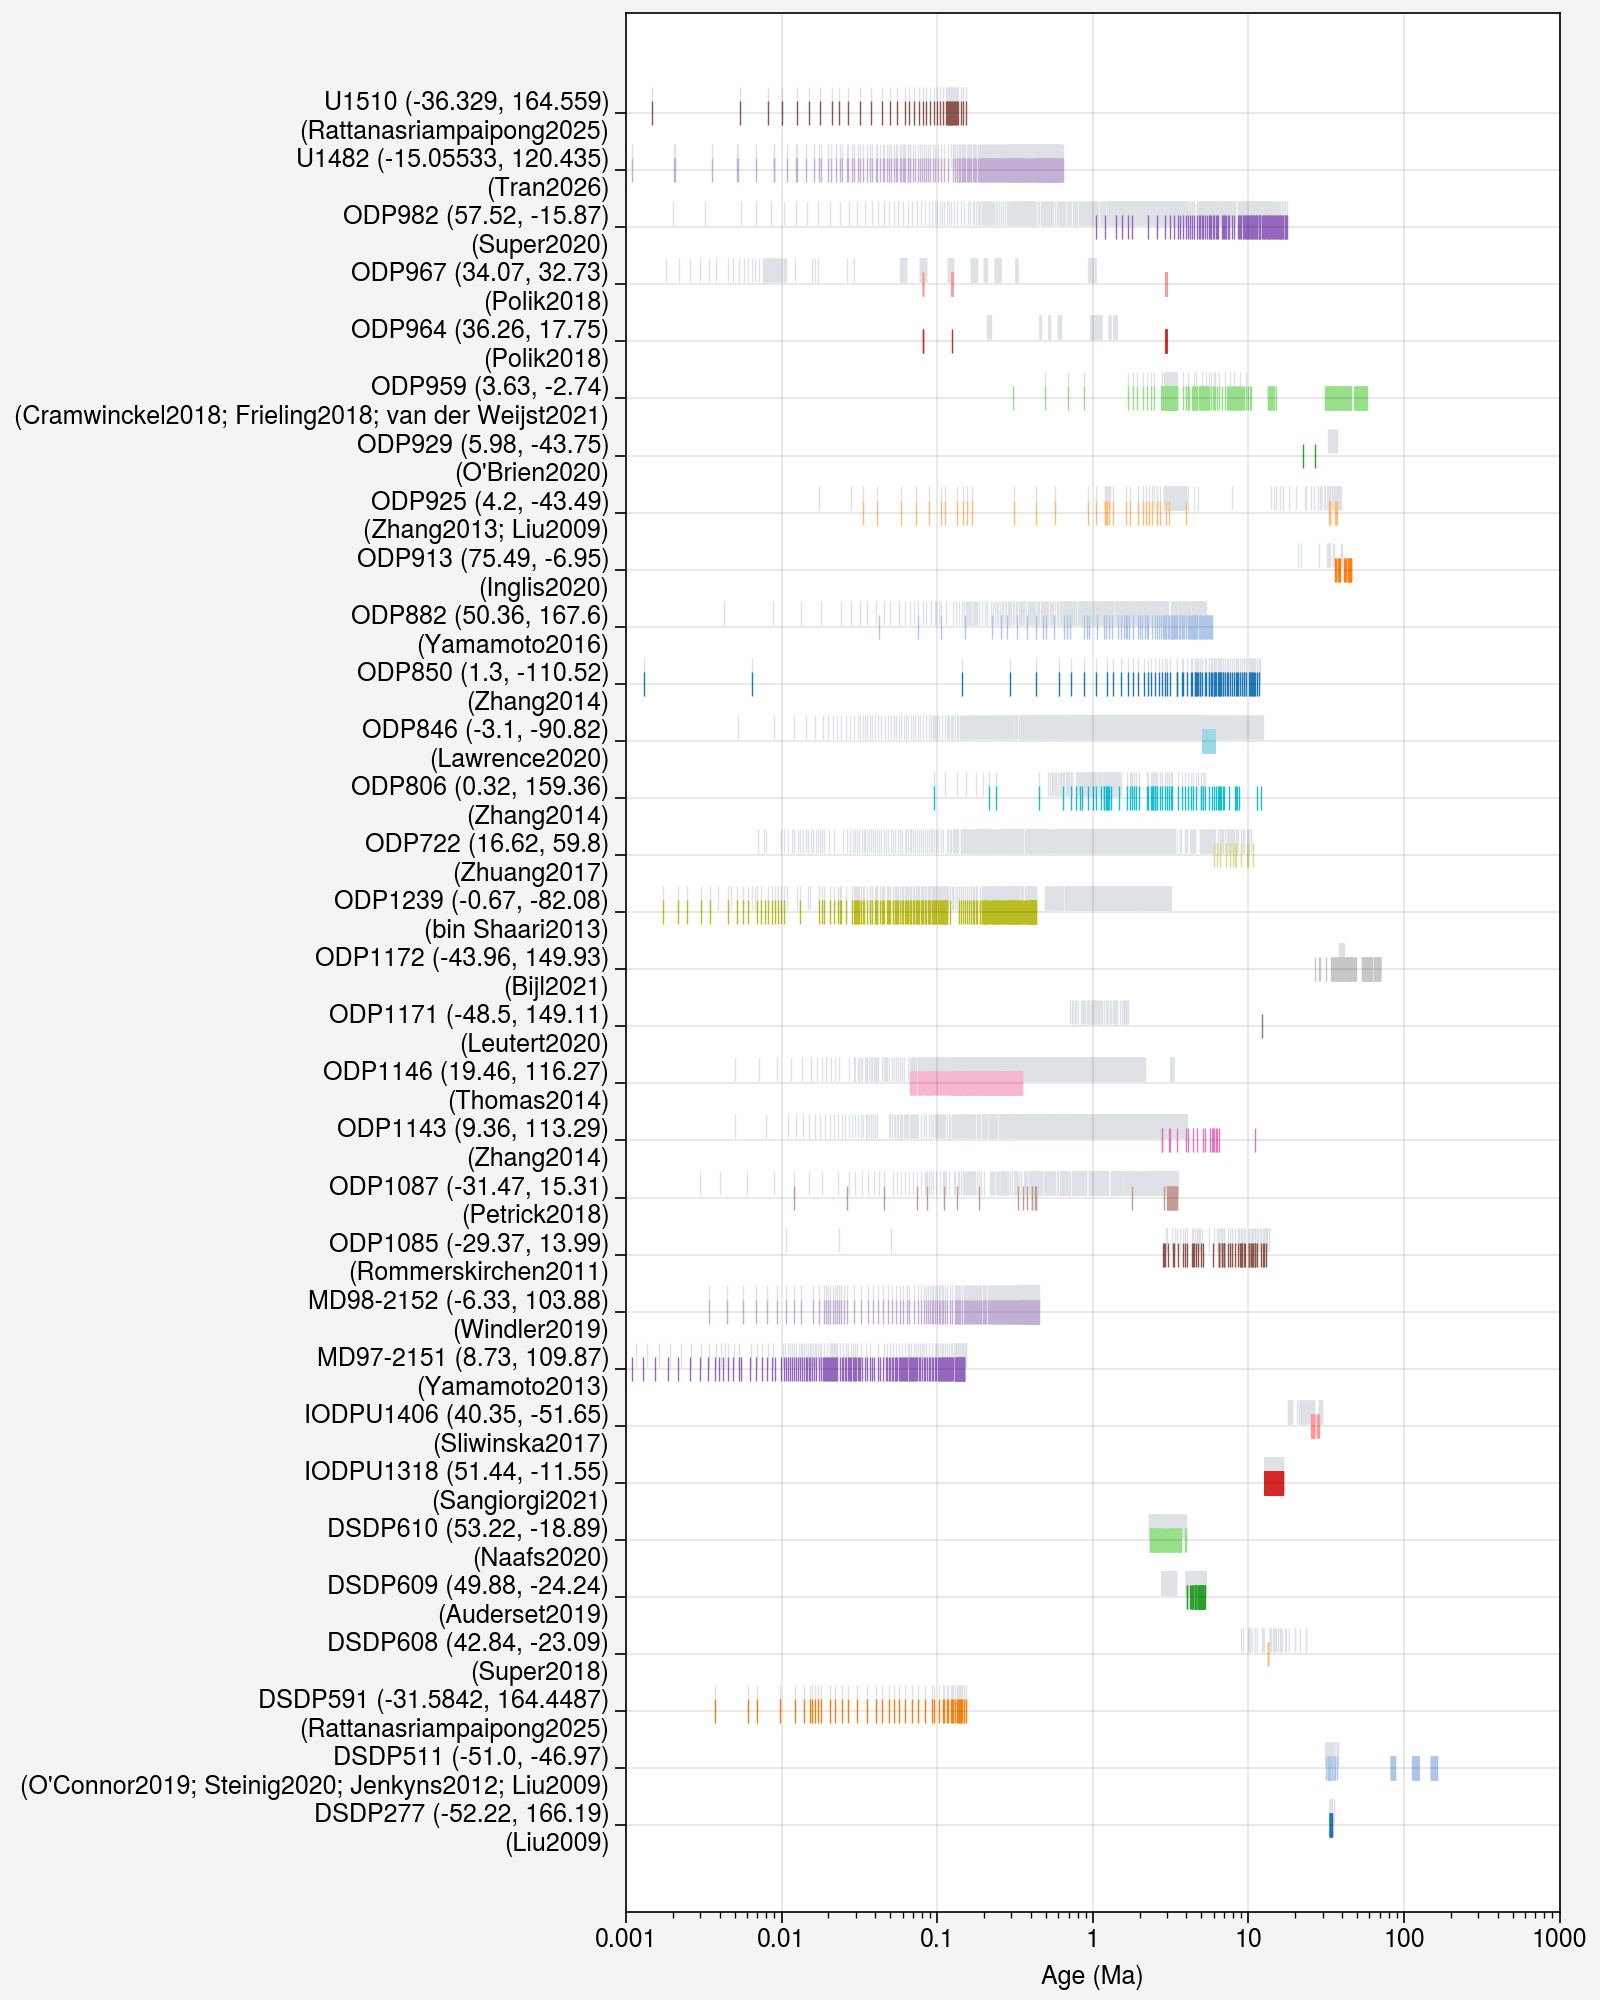

In [17]:
fig, axs = plot.subplots(width=8,height=10)
grouped_tex_df = PhanTEX_df[PhanTEX_df['TEXRI_mahalDist_low23ratio_outliers_manual']==False].groupby('SiteName')

ax = axs[0]
jj = 0
y_tick_labels = []
for j, (group_name, group_data) in enumerate(grouped_tex_df):
    if group_name in PhanAlk_df['SiteName'].unique():
        # print(f"Site: {group_name}")
        if not group_data.empty:
            plot_age = group_data['Age'].values
            j_pos_array = np.full_like(plot_age, jj, dtype=float)
            ax.scatter(plot_age, j_pos_array, m='|', s=80, lw=0.5, cycle='tab20')
            
            max_age = group_data['Age'].max()
            site_lat = group_data['ModLat'].unique()[0]
            site_lon = group_data['ModLon'].unique()[0]
            pubYear = group_data['pubYear'].unique()

            label_text = f"{group_name} ({site_lat}, {site_lon})\n({'; '.join([str(year) for year in pubYear])})"
            # group_name + f' ({(site_lat)}, {(site_lon)}) [' + [f'{year};' if len(pubYear) > 1 else f'{year}' for year in pubYear] + ']',
            y_tick_labels.append(label_text)
            # ax.text(max_age+10, jj, 
            #         label_text,
            #         fontsize=8, ha='left', va='center', color='black')
            
        sel_uk_data = PhanAlk_df[PhanAlk_df['SiteName']==group_name]    
        if not sel_uk_data.empty:
            plot_age_uk = sel_uk_data['Age'].values
            j_pos_array_uk = np.full_like(plot_age_uk, jj+0.25, dtype=float)
            ax.scatter(plot_age_uk, j_pos_array_uk, m='|', s=80, lw=0.5, color='gray3', zorder=0)
            
        jj += 1
                
        
ax.format(
    xscale='log',
    xlim=(1e-3, 1e3),
    # xtickrange=(1e-4, 1e4),
    xlabel='Age (Ma)',
    yticklabels=y_tick_labels,
    yticks=np.arange(len(y_tick_labels)),
    ytickminor=False,
)

In [18]:
PhanAlk_GIG_df = PhanAlk_df[PhanAlk_df['SiteName'].isin(['MD97-2151','MD98-2152','ODP1239','U1510','U1482','DSDP591'])].reset_index(drop=True)
PhanAlk_GIG_df['predSST'] = bsl.predict_sst(PhanAlk_GIG_df['Uk37'],prior_std=10).percentile(50)

100%|██████████| 500/500 [00:19<00:00, 25.70it/s]


In [19]:
# PhanTEX_GIG_df = PhanTEX_df[
#     PhanTEX_df['SiteName'].isin(['MD97-2151', 'MD98-2152', 'ODP1239', 'U1510', 'U1482', 'DSDP591'])
# ].reset_index(drop=True)

# # ── predict BAYSPAR subT and SST for GIG sites ────────────────────────────
# temp_subT_df_list = []
# temp_SST_df_list  = []

# for site_name, group in tqdm(PhanTEX_GIG_df.groupby('SiteName')):
#     tex  = group['TEX86']
#     lat  = group['paleolat'].iloc[0]
#     lon  = group['paleolon'].iloc[0]
#     sids = group['SampleID'].values   # .values avoids index misalignment

#     temp_subT_pred = bsr.predict_seatemp(
#         tex, lat=lat, lon=lon,
#         prior_mean=20, prior_std=10, temptype='subt',
#     ).percentile([5, 10, 16, 25, 50, 75, 84, 90, 95])

#     temp_subT_df_list.append(pd.DataFrame({
#         'SampleID':         sids,
#         'BAYSPAR_subT_p5':  temp_subT_pred[:, 0],
#         'BAYSPAR_subT_p16': temp_subT_pred[:, 2],
#         'BAYSPAR_subT_p25': temp_subT_pred[:, 3],
#         'BAYSPAR_subT':     temp_subT_pred[:, 4],
#         'BAYSPAR_subT_p75': temp_subT_pred[:, 5],
#         'BAYSPAR_subT_p84': temp_subT_pred[:, 6],
#         'BAYSPAR_subT_p95': temp_subT_pred[:, 8],
#     }))

#     temp_SST_pred = bsr.predict_seatemp(
#         tex, lat=lat, lon=lon,
#         prior_mean=20, prior_std=10, temptype='sst',
#     ).percentile([5, 10, 16, 25, 50, 75, 84, 90, 95])

#     temp_SST_df_list.append(pd.DataFrame({
#         'SampleID':        sids,
#         'BAYSPAR_SST_p5':  temp_SST_pred[:, 0],
#         'BAYSPAR_SST_p16': temp_SST_pred[:, 2],
#         'BAYSPAR_SST_p25': temp_SST_pred[:, 3],
#         'BAYSPAR_SST':     temp_SST_pred[:, 4],
#         'BAYSPAR_SST_p75': temp_SST_pred[:, 5],
#         'BAYSPAR_SST_p84': temp_SST_pred[:, 6],
#         'BAYSPAR_SST_p95': temp_SST_pred[:, 8],
#     }))


# BAYSPAR_subT_df = (pd.concat(temp_subT_df_list, ignore_index=True)
#                      .sort_values('SampleID').reset_index(drop=True))
# BAYSPAR_SST_df  = (pd.concat(temp_SST_df_list, ignore_index=True)
#                      .sort_values('SampleID').reset_index(drop=True))


# # ── sanity check before merging ───────────────────────────────────────────
# assert PhanTEX_GIG_df['SampleID'].duplicated().sum() == 0, "GIG base has dupes"
# assert BAYSPAR_subT_df['SampleID'].duplicated().sum() == 0, "subT df has dupes"
# assert BAYSPAR_SST_df['SampleID'].duplicated().sum() == 0,  "SST df has dupes"

# # ── merge and save ────────────────────────────────────────────────────────
# PhanTEX_GIG_df = (PhanTEX_GIG_df
#                   .merge(BAYSPAR_subT_df, on='SampleID', how='left')
#                   .merge(BAYSPAR_SST_df,  on='SampleID', how='left'))
    
# fpath = fr'{local_github_path}/data/spreadsheets/published_data'
# PhanTEX_GIG_df.to_parquet(os.path.join(fpath, 'PhanTEX_GIG_df.parquet'), index=False)
# PhanTEX_GIG_df.to_csv(os.path.join(fpath, 'PhanTEX_GIG_df.csv'), index=False)

In [20]:
fpath = fr'{local_github_path}/data/spreadsheets/published_data'
PhanTEX_GIG_df = pd.read_csv(os.path.join(fpath, 'PhanTEX_GIG_df.csv'))

# drop _x columns (original NaN placeholders) and rename _y to clean names
x_cols = [c for c in PhanTEX_GIG_df.columns if c.endswith('_x')]
PhanTEX_GIG_df = PhanTEX_GIG_df.drop(columns=x_cols)
PhanTEX_GIG_df = PhanTEX_GIG_df.rename(columns=lambda c: c.removesuffix('_y'))
PhanTEX_GIG_df

,SampleID,SiteName,MBSF,MCD,SampleDepth,ContinentOcean,ModLat,ModLon,Age,Period,...,paleolon,TEXRI_mahalDist_low23ratio_outliers_manual,mahalanobis_distance,outliers,BAYSPAR_subT_p25,BAYSPAR_subT,BAYSPAR_subT_p75,BAYSPAR_SST_p25,BAYSPAR_SST,BAYSPAR_SST_p75
0,PhanTEX_RR3408,MD97-2151,0.011778,NaN,NaN,pa,8.730,109.870,0.000914,Quaternary,...,109.87001,False,1.400613,False,23.360146,25.262347,27.173801,27.071407,28.561495,30.085807
1,PhanTEX_RR3409,MD97-2151,0.153111,NaN,NaN,pa,8.730,109.870,0.001098,Quaternary,...,109.87001,False,1.384152,False,23.134384,25.050069,27.024492,26.835529,28.357101,29.831013
2,PhanTEX_RR3410,MD97-2151,0.294444,NaN,NaN,pa,8.730,109.870,0.001281,Quaternary,...,109.87002,False,1.574134,False,24.740555,26.645511,28.539718,28.082724,29.636267,31.105502
3,PhanTEX_RR3411,MD97-2151,0.435777,NaN,NaN,pa,8.730,109.870,0.001541,Quaternary,...,109.87002,False,1.439683,False,23.399947,25.344931,27.220382,27.155987,28.643862,30.156177
4,PhanTEX_RR3412,MD97-2151,0.577111,NaN,NaN,pa,8.730,109.870,0.001851,Quaternary,...,109.87002,False,1.532148,False,24.325819,26.293564,28.174664,27.864604,29.373356,30.893973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
963,PhanTEX_RR8233,U1510,3.950000,NaN,3.95,pa,-36.329,164.559,0.135000,Quaternary,...,164.56487,False,0.816992,False,9.225610,11.791490,14.360180,10.615923,13.328683,16.091386
964,PhanTEX_RR8234,U1510,3.990000,NaN,3.99,pa,-36.329,164.559,0.136333,Quaternary,...,164.56493,False,0.729781,False,6.781564,9.436423,11.968708,8.339504,10.918022,13.546847
965,PhanTEX_RR8235,U1510,4.190000,NaN,4.19,pa,-36.329,164.559,0.142558,Quaternary,...,164.56520,False,0.686079,False,7.968580,10.313224,13.010138,9.216150,11.941283,14.739641
966,PhanTEX_RR8236,U1510,4.340000,NaN,4.34,pa,-36.329,164.559,0.146822,Quaternary,...,164.56539,False,0.510954,False,11.884210,14.388287,17.079941,13.519435,16.112948,19.074360


In [21]:
display_function_signature(predict_T_from_RI)

```python
predict_T_from_RI(
    scaledRI,
    prior_mu_t,
    prior_sigma_t,
    fwd_posterior_name=None,
    fwd_posterior=None,
    temptype=None,
    site_name=None,
    predictors=None,
    config=None,
    chains=4,
    iter_warmup=500,
    iter_sampling=1000,
    seed=42,
    constraint_type=unconstrained,
    min_temp=None,
    threads_per_chain=None,
    save_results=False,
    filename_tag=None
)
```

In [22]:
fpath = f'{local_github_path}/data/external/ncfiles'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_prop_ds = xr.open_dataset(os.path.join(fpath,fname))
ocean_prop_ds

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

In [23]:
PhanTEX_GIG_df

,SampleID,SiteName,MBSF,MCD,SampleDepth,ContinentOcean,ModLat,ModLon,Age,Period,...,paleolon,TEXRI_mahalDist_low23ratio_outliers_manual,mahalanobis_distance,outliers,BAYSPAR_subT_p25,BAYSPAR_subT,BAYSPAR_subT_p75,BAYSPAR_SST_p25,BAYSPAR_SST,BAYSPAR_SST_p75
0,PhanTEX_RR3408,MD97-2151,0.011778,NaN,NaN,pa,8.730,109.870,0.000914,Quaternary,...,109.87001,False,1.400613,False,23.360146,25.262347,27.173801,27.071407,28.561495,30.085807
1,PhanTEX_RR3409,MD97-2151,0.153111,NaN,NaN,pa,8.730,109.870,0.001098,Quaternary,...,109.87001,False,1.384152,False,23.134384,25.050069,27.024492,26.835529,28.357101,29.831013
2,PhanTEX_RR3410,MD97-2151,0.294444,NaN,NaN,pa,8.730,109.870,0.001281,Quaternary,...,109.87002,False,1.574134,False,24.740555,26.645511,28.539718,28.082724,29.636267,31.105502
3,PhanTEX_RR3411,MD97-2151,0.435777,NaN,NaN,pa,8.730,109.870,0.001541,Quaternary,...,109.87002,False,1.439683,False,23.399947,25.344931,27.220382,27.155987,28.643862,30.156177
4,PhanTEX_RR3412,MD97-2151,0.577111,NaN,NaN,pa,8.730,109.870,0.001851,Quaternary,...,109.87002,False,1.532148,False,24.325819,26.293564,28.174664,27.864604,29.373356,30.893973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
963,PhanTEX_RR8233,U1510,3.950000,NaN,3.95,pa,-36.329,164.559,0.135000,Quaternary,...,164.56487,False,0.816992,False,9.225610,11.791490,14.360180,10.615923,13.328683,16.091386
964,PhanTEX_RR8234,U1510,3.990000,NaN,3.99,pa,-36.329,164.559,0.136333,Quaternary,...,164.56493,False,0.729781,False,6.781564,9.436423,11.968708,8.339504,10.918022,13.546847
965,PhanTEX_RR8235,U1510,4.190000,NaN,4.19,pa,-36.329,164.559,0.142558,Quaternary,...,164.56520,False,0.686079,False,7.968580,10.313224,13.010138,9.216150,11.941283,14.739641
966,PhanTEX_RR8236,U1510,4.340000,NaN,4.34,pa,-36.329,164.559,0.146822,Quaternary,...,164.56539,False,0.510954,False,11.884210,14.388287,17.079941,13.519435,16.112948,19.074360


In [26]:
# from TEXAS.data.builder import InvTConfig, build_invT_inputData

# siteName_grouped = PhanTEX_GIG_df.groupby('SiteName')

# for name, group in siteName_grouped:
#     print(name)
#     #######################
#     fwd_post = "gen_logi_fixed_hier_crtp_univ_priorApprox_SST_020526"
#     predict_T_from_RI(
#         scaledRI=group['scaledRI'].astype(float).tolist(),
#         prior_mu_t = 20.0,
#         prior_sigma_t = 10,
#         fwd_posterior_name=fwd_post,
#         site_name=name,
#         save_results=True,
#         temptype='sst'
#     )

#     ########################
#     fwd_post = "gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT_020526"
#     predict_T_from_RI(
#         scaledRI=group['scaledRI'].astype(float).tolist(),
#         prior_mu_t = 20.0,
#         prior_sigma_t = 10,
#         fwd_posterior_name=fwd_post,
#         site_name=name,
#         save_results=True,
#         temptype='thermoT'
#     )
    
#     ########################
#     fwd_post = "gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.8_020526"
#     predict_T_from_RI(
#         scaledRI=group['scaledRI'].astype(float).tolist(),
#         prior_mu_t = 20.0,
#         prior_sigma_t = 10,
#         fwd_posterior_name=fwd_post,
#         predictors={
#             'gdgt23ratio':group['gdgt23ratio'].values,
#         },
#         site_name=name,
#         save_results=True,
#         temptype='sst'
#     )

#     ########################
#     fwd_post = "gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.8_020526"
#     predict_T_from_RI(
#         scaledRI=group['scaledRI'].astype(float).tolist(),
#         prior_mu_t = 20.0,
#         prior_sigma_t = 10,
#         fwd_posterior_name=fwd_post,
#         predictors={
#             'gdgt23ratio':group['gdgt23ratio'].values,
#         },
#         site_name=name,
#         save_results=True,
#         temptype='thermoT'
#     )
    
#     ########################
#     modLat = group['ModLat'].iloc[0]
#     modLon = group['ModLon'].iloc[0]
#     modern_no3 = np.atleast_1d(ocean_prop_ds['no3_sf2tc_avg'].sel(lat=modLat,lon=modLon,method='nearest').values)[0]
    
#     ########################
#     fwd_post = "gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_no3_1.8_020526"
#     predict_T_from_RI(
#         scaledRI=group['scaledRI'].astype(float).tolist(),
#         prior_mu_t = 20.0,
#         prior_sigma_t = 10,
#         fwd_posterior_name=fwd_post,
#         predictors={
#             'gdgt23ratio':group['gdgt23ratio'].values,
#             'no3':np.full(len(group), modern_no3),
#         },
#         site_name=name,
#         save_results=True,
#         temptype='sst'
#     )

#     ########################
#     fwd_post = "gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.8_020526"
#     predict_T_from_RI(
#         scaledRI=group['scaledRI'].astype(float).tolist(),
#         prior_mu_t = 20.0,
#         prior_sigma_t = 10,
#         fwd_posterior_name=fwd_post,
#         predictors={
#             'gdgt23ratio':group['gdgt23ratio'].values,
#             'no3':np.full(len(group), modern_no3),
#         },
#         site_name=name,
#         save_results=True,
#         temptype='thermoT'
#     )

In [27]:
siteName_grouped = PhanTEX_GIG_df.groupby('SiteName')

for name, group in siteName_grouped:
    ########################
    modLat = group['ModLat'].iloc[0]
    modLon = group['ModLon'].iloc[0]
    modern_no3 = np.atleast_1d(ocean_prop_ds['no3_sf2tc_avg'].sel(lat=modLat,lon=modLon,method='nearest').values)[0]
    print(name, modern_no3)

DSDP591 0.5755885
MD97-2151 0.6517099
MD98-2152 5.8978076
ODP1239 4.1553693
U1482 2.7273462
U1510 1.105346


In [57]:
siteName_list = PhanTEX_GIG_df['SiteName'].unique()


for site_name in siteName_list:
    
    idx = PhanTEX_GIG_df[PhanTEX_GIG_df['SiteName']==site_name].index
    
    fpath = f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache'
    fname = f'{site_name}_invT_gen_logi_fixed_univ_unconstrained_sst_direct.nc'
    predT_ = xr.open_dataset(os.path.join(fpath, fname))['t_est']

    PhanTEX_GIG_df.loc[idx,'pred_SST_TEXAS'] = predT_.sel(quantile=0.5).values
    PhanTEX_GIG_df.loc[idx,'pred_SST_TEXAS_p16'] = predT_.sel(quantile=0.16).values
    PhanTEX_GIG_df.loc[idx,'pred_SST_TEXAS_p25'] = predT_.sel(quantile=0.25).values
    PhanTEX_GIG_df.loc[idx,'pred_SST_TEXAS_p75'] = predT_.sel(quantile=0.75).values
    PhanTEX_GIG_df.loc[idx,'pred_SST_TEXAS_p84'] = predT_.sel(quantile=0.84).values

    ##############################

    fpath = f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache'
    fname = f'{site_name}_invT_gen_logi_fixed_univ_unconstrained_thermoT_direct.nc'
    predT_ = xr.open_dataset(os.path.join(fpath, fname))['t_est']

    PhanTEX_GIG_df.loc[idx,'pred_thermoT_TEXAS'] = predT_.sel(quantile=0.5).values
    PhanTEX_GIG_df.loc[idx,'pred_thermoT_TEXAS_p25'] = predT_.sel(quantile=0.25).values
    PhanTEX_GIG_df.loc[idx,'pred_thermoT_TEXAS_p75'] = predT_.sel(quantile=0.75).values
    PhanTEX_GIG_df.loc[idx,'pred_thermoT_TEXAS_p16'] = predT_.sel(quantile=0.16).values
    PhanTEX_GIG_df.loc[idx,'pred_thermoT_TEXAS_p84'] = predT_.sel(quantile=0.84).values
    
    ##############################

    fpath = f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache'
    fname = f'{site_name}_invT_gen_logi_fixed_multiv_unconstrained_sst_gdgt23ratio_no3_0.0_direct.nc'
    predT_ = xr.open_dataset(os.path.join(fpath, fname))['t_est']

    PhanTEX_GIG_df.loc[idx,'pred_SST_TEXAS_Tg23r'] = predT_.sel(quantile=0.5).values
    PhanTEX_GIG_df.loc[idx,'pred_SST_TEXAS_Tg23r_p25'] = predT_.sel(quantile=0.25).values
    PhanTEX_GIG_df.loc[idx,'pred_SST_TEXAS_Tg23r_p75'] = predT_.sel(quantile=0.75).values
    PhanTEX_GIG_df.loc[idx,'pred_SST_TEXAS_Tg23r_p16'] = predT_.sel(quantile=0.16).values
    PhanTEX_GIG_df.loc[idx,'pred_SST_TEXAS_Tg23r_p84'] = predT_.sel(quantile=0.84).values
    
    ##############################

    fpath = f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache'
    fname = f'{site_name}_invT_gen_logi_fixed_multiv_unconstrained_thermoT_gdgt23ratio_no3_0.0_direct.nc'
    predT_ = xr.open_dataset(os.path.join(fpath, fname))['t_est']

    PhanTEX_GIG_df.loc[idx,'pred_thermoT_TEXAS_Tg23r'] = predT_.sel(quantile=0.5).values
    PhanTEX_GIG_df.loc[idx,'pred_thermoT_TEXAS_Tg23r_p25'] = predT_.sel(quantile=0.25).values
    PhanTEX_GIG_df.loc[idx,'pred_thermoT_TEXAS_Tg23r_p75'] = predT_.sel(quantile=0.75).values
    PhanTEX_GIG_df.loc[idx,'pred_thermoT_TEXAS_Tg23r_p16'] = predT_.sel(quantile=0.16).values
    PhanTEX_GIG_df.loc[idx,'pred_thermoT_TEXAS_Tg23r_p84'] = predT_.sel(quantile=0.84).values
    
    ##############################

    fpath = f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache'
    fname = f'{site_name}_invT_gen_logi_fixed_multiv_unconstrained_sst_gdgt23ratio_no3_1.8_direct.nc'
    predT_ = xr.open_dataset(os.path.join(fpath, fname))['t_est']

    PhanTEX_GIG_df.loc[idx,'pred_SST_TEXAS_Tg23r_no3'] = predT_.sel(quantile=0.5).values
    PhanTEX_GIG_df.loc[idx,'pred_SST_TEXAS_Tg23r_no3_p25'] = predT_.sel(quantile=0.25).values
    PhanTEX_GIG_df.loc[idx,'pred_SST_TEXAS_Tg23r_no3_p75'] = predT_.sel(quantile=0.75).values
    PhanTEX_GIG_df.loc[idx,'pred_SST_TEXAS_Tg23r_no3_p16'] = predT_.sel(quantile=0.16).values
    PhanTEX_GIG_df.loc[idx,'pred_SST_TEXAS_Tg23r_no3_p84'] = predT_.sel(quantile=0.84).values
    
    ##############################

    fpath = f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache'
    fname = f'{site_name}_invT_gen_logi_fixed_multiv_unconstrained_thermoT_gdgt23ratio_no3_1.8_direct.nc'
    predT_ = xr.open_dataset(os.path.join(fpath, fname))['t_est']

    PhanTEX_GIG_df.loc[idx,'pred_thermoT_TEXAS_Tg23r_no3'] = predT_.sel(quantile=0.5).values
    PhanTEX_GIG_df.loc[idx,'pred_thermoT_TEXAS_Tg23r_no3_p25'] = predT_.sel(quantile=0.25).values
    PhanTEX_GIG_df.loc[idx,'pred_thermoT_TEXAS_Tg23r_no3_p75'] = predT_.sel(quantile=0.75).values
    PhanTEX_GIG_df.loc[idx,'pred_thermoT_TEXAS_Tg23r_no3_p16'] = predT_.sel(quantile=0.16).values
    PhanTEX_GIG_df.loc[idx,'pred_thermoT_TEXAS_Tg23r_no3_p84'] = predT_.sel(quantile=0.84).values
    

In [58]:
fpath = f'{local_github_path}/data/external/ncfiles'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_prop_ds = xr.open_dataset(os.path.join(fpath,fname))
ocean_prop_ds

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

In [59]:
fpath2 = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_04.nc'),decode_times=False).drop('time')

T_da = ts.isel(time=0).t_an.load()
T_da

<xarray.DataArray 't_an' (depth: 102, lat: 720, lon: 1440)>
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.6605101, -1.66081  , -1.65491  , ..., -1.6598101,
         -1.66031  , -1.66041  ],
        [-1.66861  , -1.66521  , -1.66721  , ..., -1.66961  ,
         -1.6665   , -1.66871  ],
        [-1.44921  , -1.44921  , -1.44921  , ..., -1.44921  ,
         -1.44921  , -1.44921  ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

In [60]:
import numpy as np
from scipy.stats import gamma
import xarray as xr

def calculate_subT_gamma(T_da, depth_dim='depth', alpha=6.5, beta=25):
    """
    Calculate gamma-weighted subsurface temperature (0-200m).
    
    Parameters:
    -----------
    T_da : xarray.DataArray
        Temperature data with depth dimension
    depth_dim : str
        Name of depth dimension (default: 'depth')
    alpha : float
        Gamma distribution shape parameter (default: 6.5)
    beta : float
        Gamma distribution scale parameter (default: 25 meters)
    
    Returns:
    --------
    subT : xarray.DataArray
        Gamma-weighted subsurface temperature
    """
    
    # Select top 200m
    T_200m = T_da.sel({depth_dim: slice(0, 200)})
    depths = T_200m[depth_dim].values
    
    # Calculate gamma weights
    # Gamma PDF: f(z; α, β) = (z^(α-1) * exp(-z/β)) / (β^α * Γ(α))
    weights = gamma.pdf(depths, a=alpha, scale=beta)
    
    # Normalize weights to sum to 1
    weights_norm = weights / np.sum(weights)
    
    # Create xarray DataArray for weights
    weights_da = xr.DataArray(
        weights_norm,
        coords={depth_dim: depths},
        dims=[depth_dim]
    )
    
    # Calculate weighted average
    subT = (T_200m * weights_da).sum(dim=depth_dim)
    
    return subT

# Usage example:
subT = calculate_subT_gamma(T_da, depth_dim='depth', alpha=6.5, beta=25)

MD97-2151 0.6517099
MD98-2152 5.8978076
U1482 2.7273462
DSDP591 0.5755885
U1510 1.105346


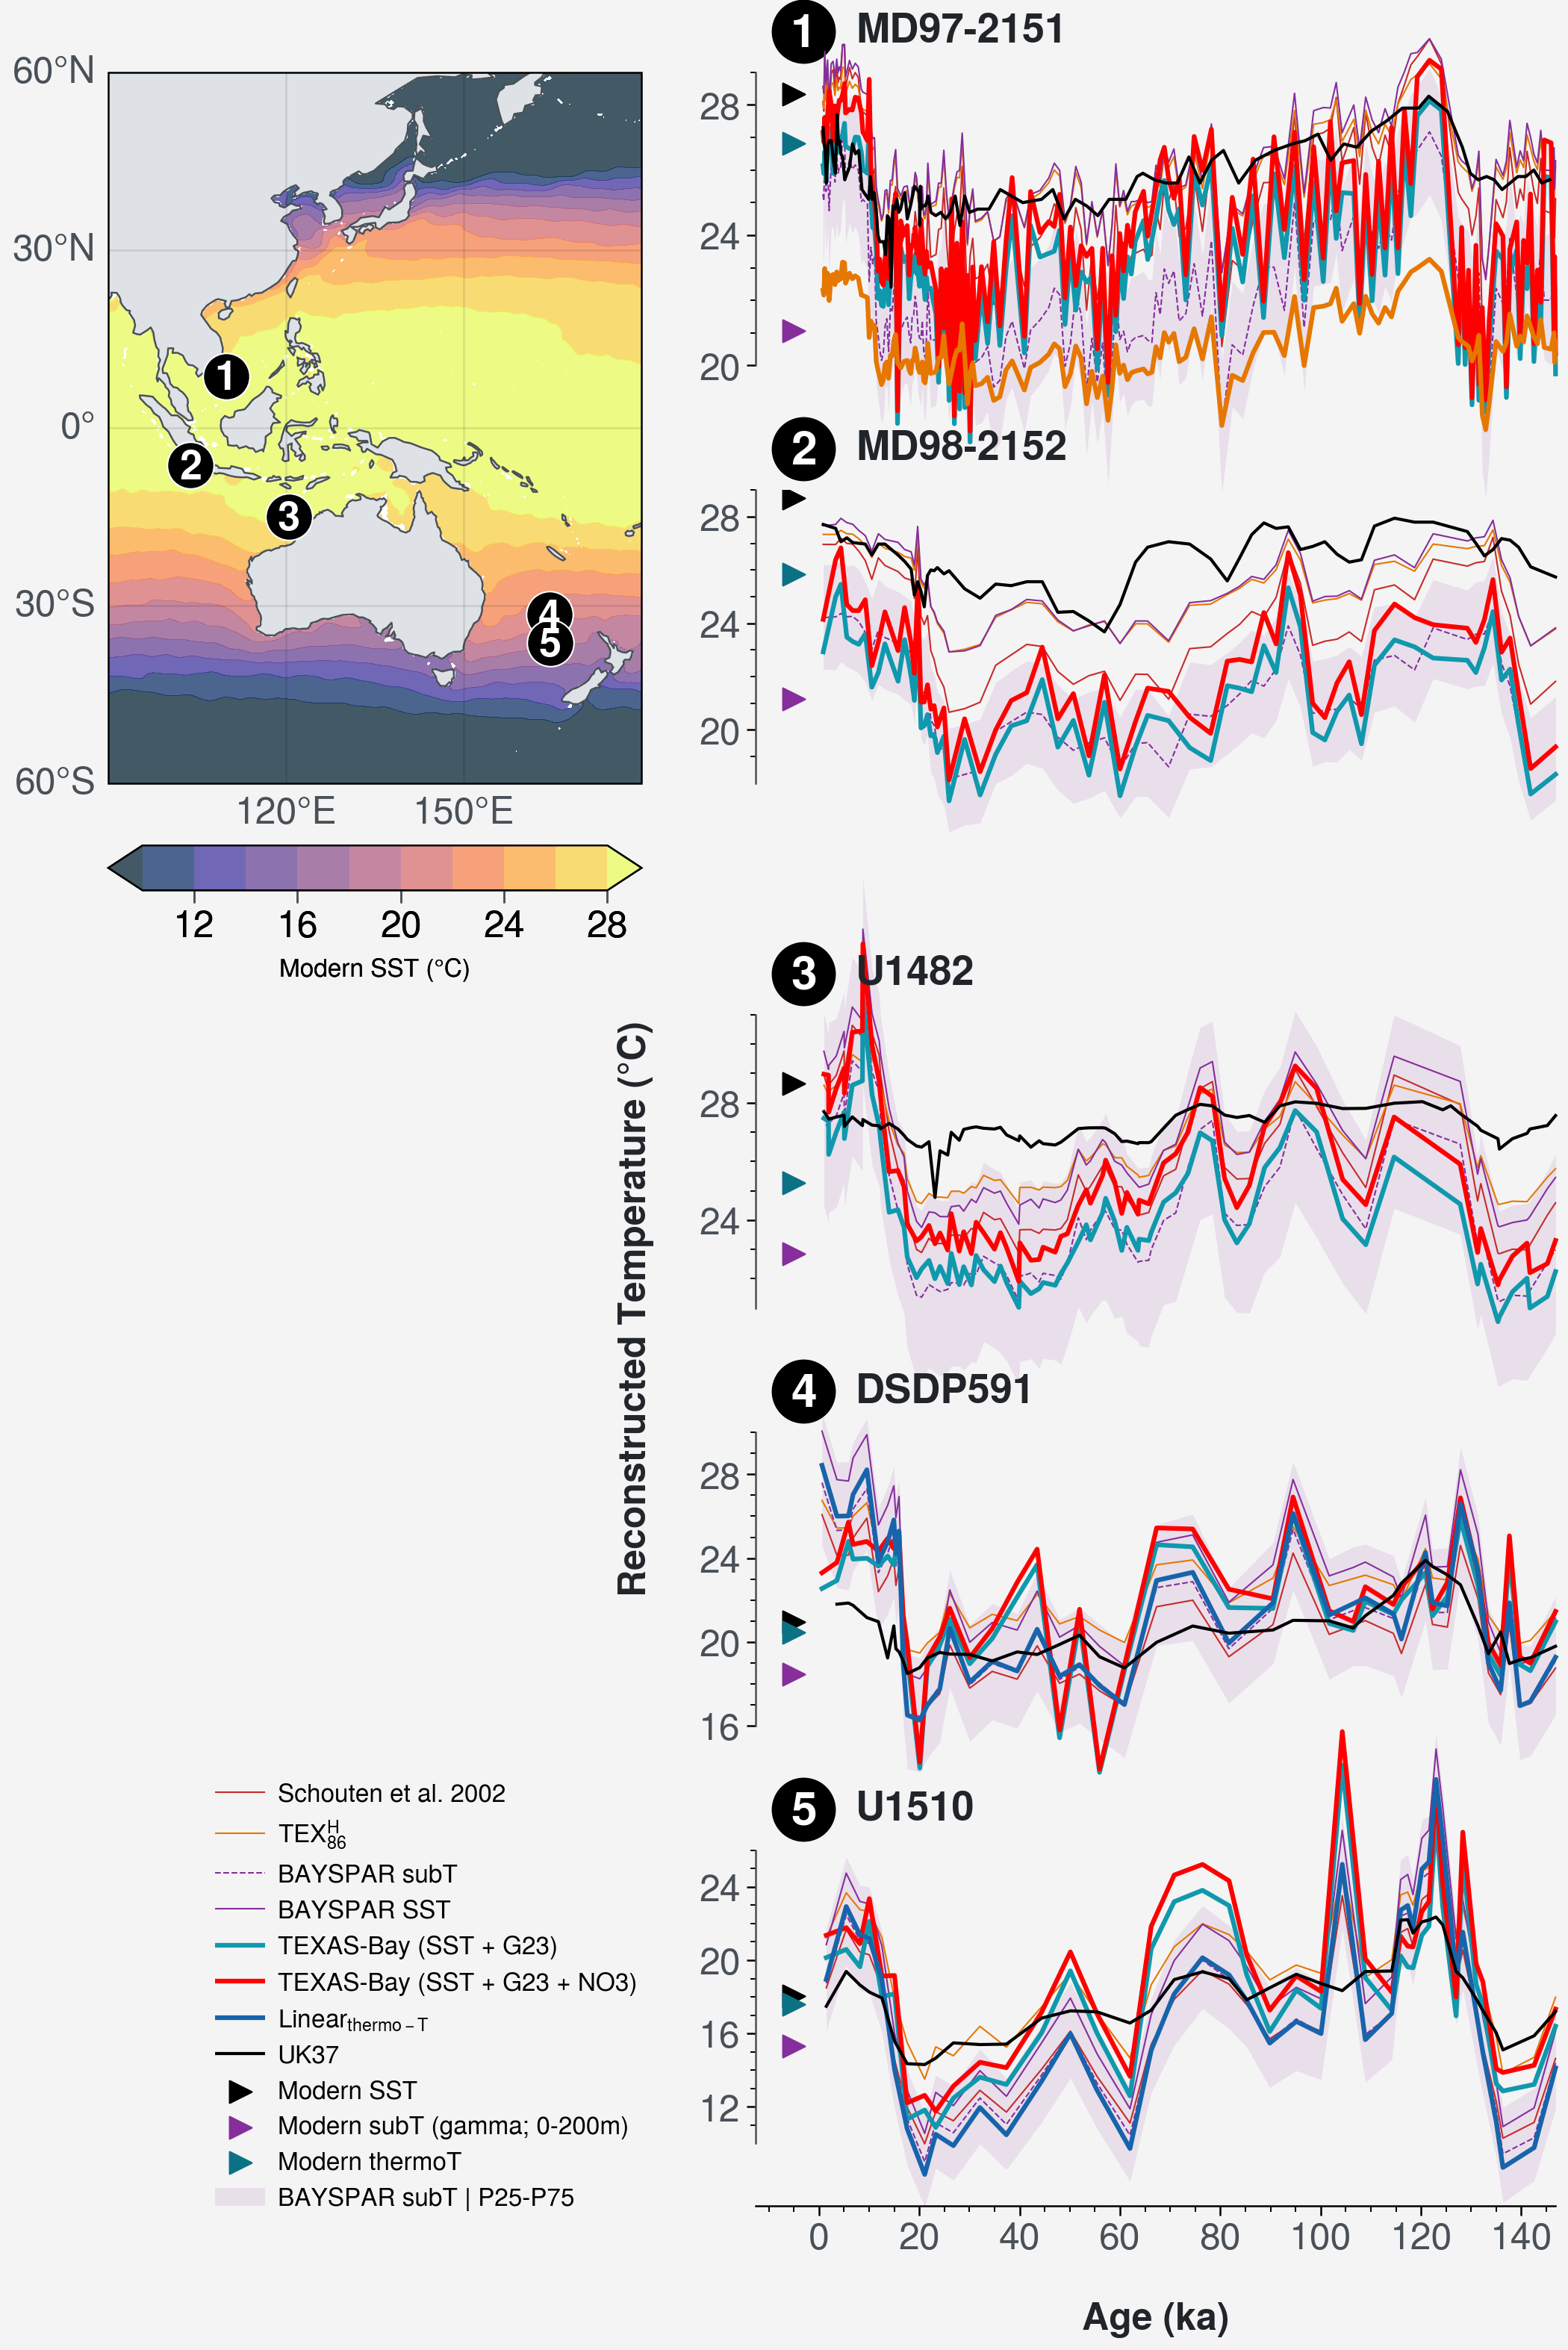

In [61]:
from cartopy import crs as ccrs

sel_age_limit = 0.15
sel_site_list = ['MD97-2151','MD98-2152','U1482','DSDP591','U1510']
plot_data = PhanTEX_GIG_df[PhanTEX_GIG_df['Age']<sel_age_limit][
    PhanTEX_GIG_df['TEXRI_mahalDist_low23ratio_outliers_manual']==False][
        PhanTEX_GIG_df['SiteName'].isin(sel_site_list)].reset_index(drop=True)
plot_data['SiteName'] = pd.Categorical(plot_data['SiteName'], categories=sel_site_list, ordered=True)

plot_alk_data = PhanAlk_GIG_df[PhanAlk_GIG_df['Age']<sel_age_limit][PhanAlk_GIG_df['SiteName'].isin(sel_site_list)].reset_index(drop=True)


array = [
        [1,2],
        [1,3],
        [0,4],
        [0,5],
        [0,6]
]
fig, axs = plot.subplots(array,width=7,proj={1:'cyl'},
                        #  wspace=3,
                        hspace=5,
                        wratios=[1,1.5],
                        share=0
                        )


ax = axs[0]
ax.format(land=True, landcolor='gray3', landzorder=0,
          coast=True, coastcolor='gray7', coastzorder=1,
          latlabels=True,lonlabels=True, latlines=30, lonlines=30,
          latlim=(-60,60),lonlim=(90,180))

plot_T = T_da.isel(depth=0).values
plot_lat = T_da['lat'].values
plot_lon = T_da['lon'].values
m = ax.contourf(plot_lon, plot_lat, plot_T, 
              levels=np.arange(10, 28.1, 2), extend='both',
              vmin=10, vmax=28,
              cmap='thermal', alpha=0.75,
              zorder=-1)
cbar = ax.colorbar(m, loc='b', label='Modern SST (°C)')
cbar.ax.tick_params(labelsize=12,color='gray7')

grouped = plot_data.groupby('SiteName')
yparam_list = ['SST_Schouten02', 'SST_Kim10', 
               'BAYSPAR_subT', 'BAYSPAR_SST', 
        #        'pred_thermoT_TEXAS_Tg23r',
               'pred_SST_TEXAS_Tg23r','pred_SST_TEXAS_Tg23r_no3']

method_color_dict = {
    'SST_Schouten02': ('red9', '-'),
    'SST_Kim10': ('yellow9', '-'),
    'BAYSPAR_SST': ('grape9', '-'),
    'BAYSPAR_subT': ('grape9', '--'),
    'pred_thermoT_TEXAS': ('blue9', '-'),
    'pred_thermoT_TEXAS_Tg23r': ('cyan9', '-'),
    'pred_SST_TEXAS': ('blue7', '-'),
    'pred_SST_TEXAS_Tg23r': ('cyan7', '-'),
    'pred_SST_TEXAS_Tg23r_no3': ('red', '-'),
}

method_label_dict = {
        'SST_Schouten02': 'Schouten et al. 2002',
        'SST_Kim10': r'TEX$^{H}_{86}$',
        'BAYSPAR_SST': 'BAYSPAR SST',
        'BAYSPAR_subT': 'BAYSPAR subT',
        'pred_thermoT_TEXAS': 'TEXAS-Bay Thermo-T',
        'pred_thermoT_TEXAS_Tg23r': 'TEXAS-Bay (Thermo-T + G23)',
        'pred_SST_TEXAS': 'TEXAS-Bay SST',
        'pred_SST_TEXAS_Tg23r': 'TEXAS-Bay (SST + G23)',
        'pred_SST_TEXAS_Tg23r_no3': 'TEXAS-Bay (SST + G23 + NO3)',
}

site_axs_dict = {
        'MD97-2151':1,
        'MD98-2152':2,
        'U1482':3,
        'DSDP591':4,
        'U1510':5
}

colors = plot.get_colors('tab10', N=int(len(yparam_list)))
for i, (group_name, group_data) in enumerate(grouped):
        modLat = group_data['ModLat'].unique()[0]
        modLon = group_data['ModLon'].unique()[0]
        
        print(group_name, ocean_prop_ds['no3_sf2tc_avg'].sel(lat=modLat,lon=modLon,method='nearest').values)
        
        axs[0].plot(modLon, modLat, 
                        marker='o', markersize=15, 
                        c='k', mec='w', mew=0.5,
                        label=group_name)
        axs[0].text(modLon, modLat-0.5, i+1,  
                        fontweight='bold', fontsize=13,
                        ha='center', va='center', color='white',
                        transform=ccrs.PlateCarree())
        
        ax = axs[site_axs_dict[group_name]]
        ax.scatter(0.06, 1.14, marker='o', color='k', markersize=400, 
                transform=ax.transAxes, clip_on=False, zorder=-1)
        ax.text(0.06, 1.13, i+1, 
                transform=ax.transAxes, 
                fontsize=15, fontweight='bold', 
                ha='center', va='center', color='white',)
        ax.text(0.125, 1.14, group_name, transform=ax.transAxes,
                fontsize=13, fontweight='bold',
                ha='left', va='center', color='gray9',)
        #     cite_name = '| '+group_data['LeadAuthor'].unique()[0] + ' et al. (' + str(group_data['Year'].unique()[0]) + ')'
        #     ax.text(0.125+len(group_name)*0.035 if len(group_name)>7 else 0.125+len(group_name)*0.038, 
        #             1.14, cite_name, transform=ax.transAxes,
        #             fontsize=11, ha='left', va='center', color='gray7',)
        
        mod_SST = T_da.isel(depth=0).sel(lat=modLat, lon=modLon, method='nearest').values
        ax.scatter(-5, mod_SST, marker='>', color='k',s=50, label='Modern SST')
        
        mod_subT_gamma = subT.sel(lat=modLat, lon=modLon, method='nearest').values
        ax.scatter(-5, mod_subT_gamma, marker='>', color=method_color_dict['BAYSPAR_subT'][0], s=50, label='Modern subT (gamma; 0-200m)')
        
        thermoT = ocean_prop_ds.sel(lat=modLat, lon=modLon, method='nearest')['t_sf2tc_avg'].values
        ax.scatter(-5, thermoT, marker='>', color=method_color_dict['pred_thermoT_TEXAS_Tg23r'][0], s=50, label='Modern thermoT')
        
        for j, yparam in enumerate(yparam_list):
                plot_age = group_data['Age'].values * 1000
                plot_TEX86 = group_data[yparam].values
                ax.plot(plot_age, plot_TEX86, 
                        label=method_label_dict[yparam], ls=method_color_dict[yparam][1], 
                        c=method_color_dict[yparam][0], 
                        lw=1.5 if 'TEXAS' in yparam else 0.5,
                        clip_on=False)
                
                if yparam == 'BAYSPAR_subT':
                        ax.fill_between(plot_age, group_data['BAYSPAR_subT_p25'], group_data['BAYSPAR_subT_p75'],
                                        c=method_color_dict[yparam][0], alpha=0.1, label=method_label_dict[yparam] + ' | P25-P75',
                                        clip_on=False,lw=0)
                
                if yparam == 'pred_thermoT_TEXAS_Tg23r':
                        ax.fill_between(plot_age, group_data['pred_thermoT_TEXAS_Tg23r_p25'], 
                                        group_data['pred_thermoT_TEXAS_Tg23r_p75'], 
                                        c=method_color_dict[yparam][0], alpha=0.3, label=method_label_dict[yparam] + ' | P25-P75',
                                        clip_on=False,lw=0)
                
        if group_name == 'MD97-2151':
                published_T = 54.5*np.log10(group_data['TEX86'].values) + 30.7   ### 54.5 × TEXH86 + 30.7
                ax.plot(plot_age, published_T, label='Published',  
                        color=method_color_dict['SST_Kim10'][0], lw=1.5,
                        clip_on=False)


        if group_name in ['DSDP591','U1510']:
                ## published TEX86 thermo-T 
                published_T = (group_data['TEX86'] - 0.330)/0.012
                ax.plot(plot_age, published_T, label=r'Linear$_{thermo-T}$',
                        color='blue9', lw=1.5, clip_on=False)

        sel_alk_data = plot_alk_data[plot_alk_data['SiteName']==group_name]
        if not sel_alk_data.empty:
                plot_age_uk = sel_alk_data['Age'].values * 1000
                plot_alk = sel_alk_data['predSST'].values
                ax.plot(plot_age_uk, plot_alk, label='UK37', color='k', lw=1,
                clip_on=False)



axs[:,1].format(
        grid=False,
        yreverse=False,
        )


ylim_list = [(20,29),(18,29),(21,31),(16,30),(10,26)]
for i, ylim in enumerate(ylim_list):
    axs[i+1].format(ylim=ylim,
                    yticks=np.arange(12, ylim[1]+1, 4))

h, l = axs[-1].get_legend_handles_labels()
axs[-1].legend(h, l, loc='l', fontsize=8, ncol=1,
              bbox_to_anchor=(-0.1, 0.5), borderaxespad=0.,
              frameon=False)

for ax in axs[:,1:]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if ax != axs[-1,1]:
                ax.spines['bottom'].set_visible(False)
        
        if ax == axs[-1,1]:
                ax.spines['bottom'].set_position(('outward', 20))
        ax.format(facecolor='none',ylabel='')
        
for ax in axs:
        ax.spines['left'].set_color('gray7')
                
axs.format(
        fontsize=12,
        xticklabelcolor='gray7',
        yticklabelcolor='gray7'
)

axs[0].format(
        labelsize=12,
        labelcolor='gray7',
)

text = 'Reconstructed Temperature (°C)'
axs[2,1].text(-0.15, 0, text,
        fontsize=12, fontweight='bold', color='gray9',
        ha='center', va='center', rotation=90, transform=axs[2,1].transAxes)

text = 'Age (ka)'
axs[-1,1].text(0.5, -0.6, text,
        fontsize=12, fontweight='bold', color='gray9',
        ha='center', va='center', transform=axs[-1,1].transAxes)
plot.rc['abc'] = False

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = 'Fig12_GIG_example_sites_comparison.pdf'
fig.savefig(os.path.join(fpath, fname), dpi=300, bbox_inches='tight')

In [66]:
fwd_post = "gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_020526"
test01 = predict_T_from_RI(
    scaledRI=[0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5],
    prior_mu_t = 20.0,
    prior_sigma_t = 10,
    fwd_posterior_name=fwd_post,
    predictors={
        'gdgt23ratio':[5,5,5,5,5,5,5,5,5],
        'no3':[10,1.8,1.7,1.5,1,0.1,0.01,0.001,0.0001],
    },
    site_name='test',
    save_results=True,
    temptype='SST',
)['p50']
test01

18:14:59 - cmdstanpy - INFO - CmdStan start processing


⚙️  Auto M=500 (4000 posterior draws available; approx. error ≈ 4.5%). Override with InvTConfig(n_draws=...).
🔧 Automatically selected Stan file: invT_gen_logi_fixed_multiv_marginal_unconstrained.stan
⚙️  Auto CPU config: 4 parallel chains, 5 threads/chain (reduce_sum model)
| M=500 N=9
♻️  Using cached model: invT_gen_logi_fixed_multiv_marginal_unconstrained.stan
Starting Stan sampling with 9 observations...


chain 1:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

18:15:03 - cmdstanpy - INFO - CmdStan done processing.



✅ Stan sampling completed successfully
✅ Posterior saved to /home/micromamba/app/data/cache/TEXAS_invT_posterior_cache/test_invT_gen_logi_fixed_multiv_unconstrained_SST_gdgt23ratio_direct.nc
✅ invT results saved: /home/micromamba/app/data/cache/TEXAS_invT_posterior_cache/test_invT_gen_logi_fixed_multiv_unconstrained_SST_gdgt23ratio_direct.npz


array([12.89615, 13.0102 , 12.99815, 12.95225, 12.8148 , 12.98935,
       13.01965, 12.96515, 13.0412 ])

In [ ]:
post = load_posterior("gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_020526")
print(post.attrs.get("use_no3"))       # → 0                                                                                           
print(post.attrs.get("no3_cutoff"))    # → 0.0 or absent                                                                               

None
None


In [70]:
fwd_post = "gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_020526"
test01a = predict_T_from_RI(
    scaledRI=[0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5],
    prior_mu_t = 20.0,
    prior_sigma_t = 10,
    fwd_posterior_name=fwd_post,
    predictors={
        'gdgt23ratio':[5,5,5,5,5,5,5,5,5],
        'no3':[10,1.8,1.7,1.5,1,0.1,0.01,0.001,0.0001],
    },
    site_name='test',
    save_results=True,
    temptype='SST',
    iter_sampling=5000
)['p50']
print(np.std(test01a))

18:20:29 - cmdstanpy - INFO - CmdStan start processing


⚙️  Auto M=500 (4000 posterior draws available; approx. error ≈ 4.5%). Override with InvTConfig(n_draws=...).
🔧 Automatically selected Stan file: invT_gen_logi_fixed_multiv_marginal_unconstrained.stan
⚙️  Auto CPU config: 4 parallel chains, 5 threads/chain (reduce_sum model)
| M=500 N=9
♻️  Using cached model: invT_gen_logi_fixed_multiv_marginal_unconstrained.stan
Starting Stan sampling with 9 observations...


chain 1:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

18:20:44 - cmdstanpy - INFO - CmdStan done processing.



✅ Stan sampling completed successfully
✅ Posterior saved to /home/micromamba/app/data/cache/TEXAS_invT_posterior_cache/test_invT_gen_logi_fixed_multiv_unconstrained_SST_gdgt23ratio_direct.nc
✅ invT results saved: /home/micromamba/app/data/cache/TEXAS_invT_posterior_cache/test_invT_gen_logi_fixed_multiv_unconstrained_SST_gdgt23ratio_direct.npz
0.04254289991682911


In [ ]:
fwd_post = "gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_no3_1.8_020526"
test02 = predict_T_from_RI(
    scaledRI=[0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5],
    prior_mu_t = 20.0,
    prior_sigma_t = 10,
    fwd_posterior_name=fwd_post,
    predictors={
        'gdgt23ratio':[5,5,5,5,5,5,5,5,5],
        'no3':[10,1.8,1.7,1.5,1,0.1,0.01,0.001,0.0001],
    },
    site_name='test',
    save_results=True,
    temptype='SST',
)['p50']
test02

In [72]:
fwd_post = "gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_no3_1.8_020526"
test02b = predict_T_from_RI(
    scaledRI=[0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5],
    prior_mu_t = 20.0,
    prior_sigma_t = 10,
    fwd_posterior_name=fwd_post,
    predictors={
        'gdgt23ratio':[0,1,2,3,4,5,6,7,8],
        'no3':[10,10,10,10,10,10,10,10,10],
    },
    site_name='test',
    save_results=True,
    temptype='SST',
)['p50']
test02b

13:49:23 - cmdstanpy - INFO - CmdStan start processing


⚙️  Auto M=500 (4000 posterior draws available; approx. error ≈ 4.5%). Override with InvTConfig(n_draws=...).
💡 Using no3_cutoff from forward posterior attributes: 1.8
🔧 Automatically selected Stan file: invT_gen_logi_fixed_multiv_marginal_unconstrained.stan
⚙️  Auto CPU config: 4 parallel chains, 5 threads/chain (reduce_sum model)
| M=500 N=9
♻️  Using cached model: invT_gen_logi_fixed_multiv_marginal_unconstrained.stan
Starting Stan sampling with 9 observations...


chain 1:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

13:49:28 - cmdstanpy - INFO - CmdStan done processing.



✅ Stan sampling completed successfully
✅ Posterior saved to /home/micromamba/app/data/cache/TEXAS_invT_posterior_cache/test_invT_gen_logi_fixed_multiv_unconstrained_SST_gdgt23ratio_no3_1.8_direct.nc
✅ invT results saved: /home/micromamba/app/data/cache/TEXAS_invT_posterior_cache/test_invT_gen_logi_fixed_multiv_unconstrained_SST_gdgt23ratio_no3_1.8_direct.npz


array([10.8911 , 11.3602 , 11.8277 , 12.30005, 12.7953 , 13.3451 ,
       13.93315, 14.42325, 15.10005])

In [4]:
fig, axs = plot.subplots()
ax = axs[0]
ax.scatter(combined_df_raw['gdgt23ratio'],combined_df_raw['modernWaterDepth'])

ax.format(ylim=(10000,1),yscale='log',
          xlim=(0,10))

model = LinearRegression()

idx = combined_df_raw[combined_df_raw['datatype']=='coretop'][combined_df_raw['modernWaterDepth']]
reg_data = 

SyntaxError: invalid syntax (2422177728.py, line 11)

In [ ]:
fwd_post = "gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_no3_1.8_020526"
test02 = predict_T_from_RI(
    scaledRI=[0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5],
    prior_mu_t = 20.0,
    prior_sigma_t = 10,
    fwd_posterior_name=fwd_post,
    predictors={
        'gdgt23ratio':[5,5,5,5,5,5,5,5,5],
        'no3':[10,1.8,1.7,1.5,1,0.1,0.01,0.001,0.0001],
    },
    site_name='test',
    save_results=True,
    temptype='SST',
)['p50']
test02

18:15:06 - cmdstanpy - INFO - CmdStan start processing


⚙️  Auto M=500 (4000 posterior draws available; approx. error ≈ 4.5%). Override with InvTConfig(n_draws=...).
💡 Using no3_cutoff from forward posterior attributes: 1.8
🔧 Automatically selected Stan file: invT_gen_logi_fixed_multiv_marginal_unconstrained.stan
⚙️  Auto CPU config: 4 parallel chains, 5 threads/chain (reduce_sum model)
| M=500 N=9
♻️  Using cached model: invT_gen_logi_fixed_multiv_marginal_unconstrained.stan
Starting Stan sampling with 9 observations...


chain 1:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

18:15:12 - cmdstanpy - INFO - CmdStan done processing.



✅ Stan sampling completed successfully
✅ Posterior saved to /home/micromamba/app/data/cache/TEXAS_invT_posterior_cache/test_invT_gen_logi_fixed_multiv_unconstrained_SST_gdgt23ratio_no3_1.8_direct.nc
✅ invT results saved: /home/micromamba/app/data/cache/TEXAS_invT_posterior_cache/test_invT_gen_logi_fixed_multiv_unconstrained_SST_gdgt23ratio_no3_1.8_direct.npz


array([13.23705, 13.50125, 14.12375, 13.7143 , 13.48115, 10.8003 ,
        8.71656,  6.62533,  4.66972])

In [ ]:
fwd_post = "gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_no3_1.8_020526"
load_posterior(fwd_post)

<xarray.Dataset>
Dimensions:              (chain: 4, draw: 1000)
Coordinates:
  * chain                (chain) int64 1 2 3 4
  * draw                 (draw) int64 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
Data variables:
    t0_crtp              (chain, draw) float64 30.71 30.27 32.3 ... 34.55 40.69
    k_crtp               (chain, draw) float64 0.2031 0.2023 ... 0.1744 0.1539
    b_crtp               (chain, draw) float64 0.4374 0.4438 ... 0.4366 0.4372
    Q_crtp               (chain, draw) float64 3.34 3.585 2.976 ... 1.447 0.4987
    v_crtp               (chain, draw) float64 2.693 2.639 2.921 ... 2.419 2.055
    beta_G23_crtp        (chain, draw) float64 -0.006013 -0.006221 ... -0.006214
    beta_NO3_crtp        (chain, draw) float64 -0.03421 -0.03159 ... -0.0337
    sigma_scaledRI_crtp  (chain, draw) float64 0.05103 0.04981 ... 0.05214
Attributes: (12/44)
    stan_version:                 2.36.0
    model:                        gen_logi_fixed_hier_crtp_multiv_priorApprox...
    num_draws_sampling:           1000
    stan_model_name:              gen_logi_fixed_hier_crtp_multiv_priorApprox
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    ...                           ...
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1439.9
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS
    filename:                     gen_logi_fixed_hier_crtp_multiv_priorApprox...

In [ ]:
fwd_post = "gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_no3_1.8_020526"
test02 = predict_T_from_RI(
    scaledRI=[0.5],
    prior_mu_t = 20.0,
    prior_sigma_t = 10,
    fwd_posterior_name=fwd_post,
    predictors={
        'gdgt23ratio':[5],
        'no3':[0.65],
    },
    site_name='test',
    save_results=True
)['p50']
test02

17:53:00 - cmdstanpy - INFO - CmdStan start processing


⚙️  Auto M=500 (4000 posterior draws available; approx. error ≈ 4.5%). Override with InvTConfig(n_draws=...).
💡 Using no3_cutoff from forward posterior attributes: 1.8
🔧 Automatically selected Stan file: invT_gen_logi_fixed_multiv_marginal_unconstrained.stan
⚙️  Auto CPU config: 4 parallel chains, 5 threads/chain (reduce_sum model)
| M=500 N=1
♻️  Using cached model: invT_gen_logi_fixed_multiv_marginal_unconstrained.stan
Starting Stan sampling with 1 observations...


chain 1:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

17:53:00 - cmdstanpy - INFO - CmdStan done processing.



✅ Stan sampling completed successfully
✅ Posterior saved to /home/micromamba/app/data/cache/TEXAS_invT_posterior_cache/test_invT_gen_logi_fixed_multiv_unconstrained_SST_gdgt23ratio_no3_1.8_direct.nc
✅ invT results saved: /home/micromamba/app/data/cache/TEXAS_invT_posterior_cache/test_invT_gen_logi_fixed_multiv_unconstrained_SST_gdgt23ratio_no3_1.8_direct.npz


array([12.71615])

In [ ]:
import xarray as xr
import xesmf as xe
import numpy as np
import gc
import os
import hashlib

def regrid_curvilinear_to_latlon(
    ds,
    var_names,
    lat_name=None,
    lon_name=None,
    target_res=0.5,
    lat_range=(-90, 90),
    lon_range=(0, 360),
    method='bilinear',
    periodic=True,
    squeeze_dims=None,
    keep_attrs=True,
):
    """
    Regrid data from curvilinear grid to regular lat/lon grid.
    """
    regridder = None
    
    # Create unique weight filename based on grid configuration
    grid_config = f"{method}_{target_res}_{lat_range[0]}_{lat_range[1]}_{lon_range[0]}_{lon_range[1]}"
    grid_hash = hashlib.md5(grid_config.encode()).hexdigest()[:8]
    weight_file = f'regrid_weights_{grid_hash}.nc'
    
    try:
        if isinstance(var_names, str):
            var_names = [var_names]
        
        # Auto-detect lat/lon coordinate names
        if lat_name is None or lon_name is None:
            print("Auto-detecting coordinate names...")
            
            lat_candidates = ['TLAT', 'lat', 'latitude', 'LAT', 'Lat']
            lon_candidates = ['TLONG', 'lon', 'longitude', 'LON', 'Lon', 'LONG']
            
            for lat_cand in lat_candidates:
                if lat_cand in ds:
                    lat_name = lat_cand
                    print(f"  Found latitude: {lat_name}")
                    break
            
            for lon_cand in lon_candidates:
                if lon_cand in ds:
                    lon_name = lon_cand
                    print(f"  Found longitude: {lon_name}")
                    break
            
            if lat_name is None or lon_name is None:
                raise ValueError(
                    f"Could not auto-detect coordinates.\n"
                    f"Available variables: {list(ds.variables)}\n"
                    f"Please specify lat_name and lon_name explicitly."
                )
        
        # Get dimensions
        lat_dims = ds[lat_name].dims
        lon_dims = ds[lon_name].dims
        
        if lat_dims != lon_dims:
            raise ValueError(
                f"Latitude and longitude have different dimensions:\n"
                f"  {lat_name}: {lat_dims}\n"
                f"  {lon_name}: {lon_dims}"
            )
        
        if len(lat_dims) != 2:
            raise ValueError(
                f"Expected 2D coordinates, got {len(lat_dims)}D: {lat_dims}"
            )
        
        lat_dim, lon_dim = lat_dims
        print(f"  Dimensions: {lat_dim}, {lon_dim}")
        
        # Get source coordinates
        lat_vals = ds[lat_name].values.copy()
        lon_vals = ds[lon_name].values.copy()
        
        print(f"\nSource coordinates:")
        print(f"  Lat range: [{lat_vals.min():.2f}, {lat_vals.max():.2f}]")
        print(f"  Lon range: [{lon_vals.min():.2f}, {lon_vals.max():.2f}]")
        
        # Convert source longitudes if needed
        if lon_range[0] < 0 and lon_vals.min() >= 0:
            # Target is -180-180 but source is 0-360
            print(f"  Converting source lon from [0, 360] to [-180, 180]...")
            lon_vals = np.where(lon_vals > 180, lon_vals - 360, lon_vals)
            print(f"  New lon range: [{lon_vals.min():.2f}, {lon_vals.max():.2f}]")
        elif lon_range[0] >= 0 and lon_vals.min() < 0:
            # Target is 0-360 but source is -180-180
            print(f"  Converting source lon from [-180, 180] to [0, 360]...")
            lon_vals = np.where(lon_vals < 0, lon_vals + 360, lon_vals)
            print(f"  New lon range: [{lon_vals.min():.2f}, {lon_vals.max():.2f}]")
        
        # Create source grid
        print("\nCreating source grid...")
        ds_in = xr.Dataset({
            'lat': ([lat_dim, lon_dim], lat_vals),
            'lon': ([lat_dim, lon_dim], lon_vals),
        })
        
        # Create target grid
        print("Creating target grid...")
        print(f"  Lat range: {lat_range}")
        print(f"  Lon range: {lon_range}")
        print(f"  Resolution: {target_res}°")
        
        lat_out = np.arange(lat_range[0], lat_range[1] + target_res/2, target_res)
        lon_out = np.arange(lon_range[0], lon_range[1] + target_res/2, target_res)
        
        ds_out = xr.Dataset({
            'lat': (['lat'], lat_out),
            'lon': (['lon'], lon_out),
        })
        
        print(f"  Target grid: {len(lat_out)} x {len(lon_out)}")
        
        # Check if weight file exists
        if os.path.exists(weight_file):
            print(f"\nFound existing weight file: {weight_file}")
            reuse_weights = True
        else:
            print(f"\nWeight file not found, will create: {weight_file}")
            print(f"  (Grid config hash: {grid_hash})")
            reuse_weights = False
        
        # Create regridder
        print(f"Creating regridder (method: {method})...")
        try:
            regridder = xe.Regridder(
                ds_in, ds_out, 
                method, 
                periodic=periodic,
                filename=weight_file,
                reuse_weights=reuse_weights
            )
            print("✓ Regridder created")
        except Exception as e:
            if reuse_weights and os.path.exists(weight_file):
                print(f"⚠ Error reusing weights, deleting and recreating...")
                os.remove(weight_file)
                regridder = xe.Regridder(
                    ds_in, ds_out, 
                    method, 
                    periodic=periodic,
                    filename=weight_file,
                    reuse_weights=False
                )
                print("✓ Regridder created")
            else:
                raise e
        
        # Regrid variables
        regridded_vars = {}
        for var_name in var_names:
            print(f"\n{'='*60}")
            print(f"Regridding {var_name}...")
            print(f"{'='*60}")
            
            if var_name not in ds:
                print(f"  ⚠ Warning: {var_name} not found in dataset, skipping")
                continue
            
            var = ds[var_name]
            
            # Squeeze dimensions
            if squeeze_dims is not None:
                if isinstance(squeeze_dims, str):
                    squeeze_dims = [squeeze_dims]
                for dim in squeeze_dims:
                    if dim in var.dims:
                        var = var.squeeze(dim)
                        print(f"  Squeezed dimension: {dim}")
            
            print(f"  Original shape: {var.shape}")
            print(f"  Original dims: {var.dims}")
            
            # Find time dimension
            time_dim = None
            for dim in var.dims:
                if dim not in [lat_dim, lon_dim]:
                    time_dim = dim
                    break
            
            # Regrid
            if time_dim and time_dim in var.dims:
                print(f"  Processing {var.sizes[time_dim]} time steps...")
                regridded_list = []
                n_time = var.sizes[time_dim]
                
                for t in range(n_time):
                    print(f"    Time step {t+1}/{n_time}", end='\r')
                    chunk = var.isel({time_dim: t})
                    chunk_regrid = regridder(chunk)
                    regridded_list.append(chunk_regrid)
                    del chunk
                
                print(f"    Time step {n_time}/{n_time} - Done!     ")
                
                var_regridded = xr.concat(regridded_list, dim=time_dim)
                var_regridded = var_regridded.assign_coords({time_dim: var[time_dim]})
                
                del regridded_list
                gc.collect()
            else:
                print(f"  Processing single time step...")
                var_regridded = regridder(var)
            
            # Assign coordinates
            var_regridded = var_regridded.assign_coords({
                'lat': ds_out.lat,
                'lon': ds_out.lon,
            })
            
            if keep_attrs:
                var_regridded.attrs = var.attrs
            
            regridded_vars[var_name] = var_regridded
            print(f"  ✓ {var_name} regridded successfully")
            print(f"  Output shape: {var_regridded.shape}")
        
        # Create output dataset
        ds_regridded = xr.Dataset(regridded_vars)
        
        if keep_attrs:
            ds_regridded.attrs = ds.attrs
        
        print(f"\n{'='*60}")
        print("✓ ALL VARIABLES REGRIDDED SUCCESSFULLY!")
        print(f"  Weight file: {weight_file}")
        print(f"  Variables: {list(regridded_vars.keys())}")
        print(f"  Output lon range: [{ds_regridded.lon.min().values:.2f}, {ds_regridded.lon.max().values:.2f}]")
        print(f"{'='*60}")
        
        return ds_regridded
        
    finally:
        # Cleanup
        if regridder is not None:
            print("\nCleaning up...")
            del regridder
        
        gc.collect()
        print("✓ Cleanup complete")

In [ ]:
fpath2 = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_01.nc'),decode_times=False).drop('time')

T_1deg_da = ts.isel(time=0).t_an.load()
T_1deg_da

<xarray.DataArray 't_an' (depth: 102, lat: 180, lon: 360)>
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.6392   , -1.64001  , -1.64101  , ..., -1.63711  ,
         -1.6377   , -1.63831  ],
        [-1.6605101, -1.66081  , -1.66111  , ..., -1.6593   ,
         -1.65961  , -1.6601   ],
        [-1.67591  , -1.67591  , -1.67591  , ..., -1.67591  ,
         -1.67591  , -1.67591  ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

# PETM climate simulations and PETM-DA

In [ ]:
# import glob
# import re

# fpath = f'{local_github_path}/data/external/ncfiles/Zhu19_Science_EoceneSim'
# fname = f'b.e12.B1850C5CN.f19_g16.iPETM09x.01.pop.h.1901-2000.climo.nc'

# pattern = os.path.join(fpath, '*iPETM*pop.h*.nc')
# ### find files with iPETM and pop.h in the name
# ipetm_re = re.compile(r'iPETM\d+x')


# matches = glob.glob(pattern)

# for fn in glob.glob(pattern):
#     basename = os.path.basename(fn)
#     m = ipetm_re.search(basename)
#     if m:
#         print(m.group(0))   # → iPETM09x
#         print(basename)
#     else:
#         print(f"No iPETM token found in {basename}")
    
    
#     ds = xr.open_dataset(fn)
#     display(ds)
    
#     break 

#     ds = ds.drop_vars(["ULONG", "ULAT"], errors="ignore")

#     ds_TEMP = ds['TEMP']
#     ds_TEMP['lat'] = ds_TEMP['TLAT'].copy()
#     ds_TEMP['lon'] = ds_TEMP['TLONG'].copy()

#     # 1. Define your target grid
#     lat_out = np.arange(T_1deg_da.lat.min(), T_1deg_da.lat.max()+0.1, 1.0)
#     lon_out = np.arange(T_1deg_da.lon.min(), T_1deg_da.lon.max()+0.1, 1.0)
    
#     ds_out = xr.Dataset({
#         "lat": (["lat"], lat_out),
#         "lon": (["lon"], lon_out),
#     })

#     # 2. Create the regridder and interpolate
#     regridder = xe.Regridder(ds_TEMP, ds_out, "bilinear", periodic=True)
#     field_reg = regridder(ds_TEMP)
#     field_reg.name = 'TEMP'

#     fpath = f'{local_github_path}/data/external/ncfiles/Zhu19_Science_EoceneSim/fullDepth_regridded_iPETM'
#     fname = f'Zhu19_Science_EoceneSim_fullDepth_regridded_{m.group(0)}.nc'
    
#     field_reg.to_netcdf(os.path.join(fpath, fname), mode='w', format='NETCDF4', unlimited_dims='time')
#     print(f"Saved regridded data to {os.path.join(fpath, fname)}")



fpath = fr'{local_github_path}/data/external/ncfiles/Zhu19_Science_EoceneSim/fullDepth_regridded_iPETM'

fname = 'Zhu19_Science_EoceneSim_fullDepth_regridded_iPETM01x.nc'
iPETM_01x_ds = xr.open_dataset(os.path.join(fpath,fname))

fname = 'Zhu19_Science_EoceneSim_fullDepth_regridded_iPETM03x.nc'
iPETM_03x_ds = xr.open_dataset(os.path.join(fpath,fname))

fname = 'Zhu19_Science_EoceneSim_fullDepth_regridded_iPETM06x.nc'
iPETM_06x_ds = xr.open_dataset(os.path.join(fpath,fname))

fname = 'Zhu19_Science_EoceneSim_fullDepth_regridded_iPETM09x.nc'
iPETM_09x_ds = xr.open_dataset(os.path.join(fpath,fname))



In [ ]:
iPETM_03x_ds

<xarray.Dataset>
Dimensions:  (time: 12, z_t: 1, lat: 180, lon: 360)
Coordinates:
  * time     (time) object 1950-08-02 12:00:00 ... 1951-07-02 12:00:00
  * z_t      (z_t) float32 500.0
  * lat      (lat) float64 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Data variables:
    TEMP     (time, z_t, lat, lon) float32 ...

In [ ]:
# fpath = fr'{local_github_path}/data/external/ncfiles/Tierney22_PNAS_PETMDA'
# fname = 'PETMDA_OCN_annual.nc'
# PETMDA_ds = xr.open_dataset(os.path.join(fpath,fname))

# PETMDA_ds_regridded = regrid_curvilinear_to_latlon(
#     PETMDA_ds,
#     var_names=['sst'],
#     target_res=1.0,
#     lat_range=(T_1deg_da.lat.min(), T_1deg_da.lat.max()+1.0),
#     lon_range=(T_1deg_da.lon.min(), T_1deg_da.lon.max()+1.0),
# )
    
# fname = 'PETMDA_OCN_annual_regridded.nc'
# PETMDA_ds_regridded.to_netcdf(os.path.join(fpath,fname), mode='w', format='NETCDF4', unlimited_dims='time')

fpath = fr'{local_github_path}/data/external/ncfiles/Tierney22_PNAS_PETMDA'
fname = 'PETMDA_OCN_annual_regridded.nc'
PETMDA_ds_regridded = xr.open_dataset(os.path.join(fpath,fname))
PETMDA_ds_regridded

<xarray.Dataset>
Dimensions:  (lat: 181, lon: 361, nTime: 2)
Coordinates:
  * lat      (lat) float64 -89.5 -88.5 -87.5 -86.5 -85.5 ... 87.5 88.5 89.5 90.5
  * lon      (lon) float64 -179.5 -178.5 -177.5 -176.5 ... 178.5 179.5 180.5
  * nTime    (nTime) int64 0 1
Data variables:
    sst      (nTime, lat, lon) float64 ...
Attributes:
    creation_date:  20-Mar-2022 13:04:58
    author:         Dr. Jessica E. Tierney, University of Arizona
    description:    Posterior annual ocean variables for the PETM DA

In [ ]:
PhanTEX_df['SST_OBrien17'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='OBrien17')


In [ ]:
site_names_list = ['Wilson Lake','ODP1172','ODP959','South Dover Bridge']
PhanTEX_PETM_df = PhanTEX_df[
  PhanTEX_df['outliers']==False][PhanTEX_df['SiteName'].isin(site_names_list)].reset_index(drop=True)

### for Bass River --- keep only samples with SampleDepth 350 - 400 m
PhanTEX_PETM_df = PhanTEX_PETM_df[~((PhanTEX_PETM_df['SiteName']=='Bass River') & 
                                    ( (PhanTEX_PETM_df['SampleDepth'] < 380) | 
                                      (PhanTEX_PETM_df['SampleDepth'] > 390)
                                    )
                                   )].reset_index(drop=True)

### for ODP1172 --- keep only samples with Age 50 - 55 Ma
PhanTEX_PETM_df = PhanTEX_PETM_df[~((PhanTEX_PETM_df['SiteName']=='ODP1172') & 
                                    ( (PhanTEX_PETM_df['Age'] < 55.85) | 
                                      (PhanTEX_PETM_df['Age'] > 56.1)
                                    )
                                   )].reset_index(drop=True)

### for IB10B --- keep only samples with SampleDepth 50 - 90 m
PhanTEX_PETM_df = PhanTEX_PETM_df[~((PhanTEX_PETM_df['SiteName']=='IB10B') & 
                                    ( (PhanTEX_PETM_df['SampleDepth'] < 60) | 
                                      (PhanTEX_PETM_df['SampleDepth'] > 95)
                                    )
                                   )].reset_index(drop=True)

### for ODP959 --- keep only samples with MBSF 790 to 810 m and pubYear Frieling2018
PhanTEX_PETM_df = PhanTEX_PETM_df[~((PhanTEX_PETM_df['SiteName']=='ODP959') & 
                                    ( (PhanTEX_PETM_df['MBSF'] < 801) | 
                                      (PhanTEX_PETM_df['MBSF'] > 810) |
                                      (PhanTEX_PETM_df['pubYear'] != 'Frieling2018')
                                    )
                                   )].reset_index(drop=True)

### for South Dover Bridge --- keep only samples with Sample Depth from 611
PhanTEX_PETM_df = PhanTEX_PETM_df[~((PhanTEX_PETM_df['SiteName']=='South Dover Bridge') & 
                                    ((PhanTEX_PETM_df['SampleDepth'] < 611) | 
                                     (PhanTEX_PETM_df['SampleDepth'] > 700)
                                    )
                                   )].reset_index(drop=True)

In [ ]:
PhanTEX_PETM_df['pubYear'].unique()

array(['Bijl2021', 'Frieling2018', 'Inglis2015', 'Zachos2006',
       'Sluijs2007', 'Inglis2023'], dtype=object)

In [ ]:
PETM_interval_dict_sampleDepth = {
    'ODP174AX Ancora': (165.5,171.5),
    'Wilson Lake': (96.5, 109.5),
    'Bass River': (382.5,386),
    'IB10B': (70,80),
    'South Dover Bridge': (630, 670),
}

PETM_interval_dict_Age = {
    'ODP1172': (55.94, 56.01),
}

PETM_interval_MBSF_dict = {
    'ODP959': (803.05,804.05),
}

### assign 'PETM', 'pre-PETM', 'post-PETM' based on Age or SampleDepth
PhanTEX_PETM_df['PETM_interval'] = 'non-PETM'
for i in range(len(PhanTEX_PETM_df)):
    site_name = PhanTEX_PETM_df.loc[i,'SiteName']
    if site_name in PETM_interval_dict_sampleDepth.keys():
        sample_depth = PhanTEX_PETM_df.loc[i,'SampleDepth']
        petm_start, petm_end = PETM_interval_dict_sampleDepth[site_name]
        print(f"Site: {site_name}, SampleDepth: {sample_depth}, PETM interval: {petm_start}-{petm_end}")
        if sample_depth >= petm_start and sample_depth <= petm_end:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'PETM'
        elif sample_depth < petm_start:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'post-PETM'
            print(f"  Assigned post-PETM")
        elif sample_depth > petm_end:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'pre-PETM'
            print(f"  Assigned pre-PETM")
    elif site_name in PETM_interval_dict_Age.keys():
        age = PhanTEX_PETM_df.loc[i,'Age']
        petm_start, petm_end = PETM_interval_dict_Age[site_name]
        print(f"Site: {site_name}, Age: {age}, PETM interval: {petm_start}-{petm_end}")
        if age >= petm_start and age <= petm_end:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'PETM'
        elif age < petm_start:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'post-PETM'
            print(f"  Assigned post-PETM")
        elif age > petm_end:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'pre-PETM'
            print(f"  Assigned pre-PETM")
    elif site_name in PETM_interval_MBSF_dict.keys():
        mbsf = PhanTEX_PETM_df.loc[i,'MBSF']
        petm_start, petm_end = PETM_interval_MBSF_dict[site_name]
        if mbsf >= petm_start and mbsf <= petm_end:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'PETM'
        elif mbsf < petm_start:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'post-PETM'
        elif mbsf > petm_end:
            PhanTEX_PETM_df.loc[i,'PETM_interval'] = 'pre-PETM'


Site: ODP1172, Age: 55.864, PETM interval: 55.94-56.01
  Assigned post-PETM
Site: ODP1172, Age: 55.8657, PETM interval: 55.94-56.01
  Assigned post-PETM
Site: ODP1172, Age: 55.8836, PETM interval: 55.94-56.01
  Assigned post-PETM
Site: ODP1172, Age: 55.8972, PETM interval: 55.94-56.01
  Assigned post-PETM
Site: ODP1172, Age: 55.8997, PETM interval: 55.94-56.01
  Assigned post-PETM
Site: ODP1172, Age: 55.9176, PETM interval: 55.94-56.01
  Assigned post-PETM
Site: ODP1172, Age: 55.9244, PETM interval: 55.94-56.01
  Assigned post-PETM
Site: ODP1172, Age: 55.9337, PETM interval: 55.94-56.01
  Assigned post-PETM
Site: ODP1172, Age: 55.9439, PETM interval: 55.94-56.01
Site: ODP1172, Age: 55.9516, PETM interval: 55.94-56.01
Site: ODP1172, Age: 55.9592, PETM interval: 55.94-56.01
Site: ODP1172, Age: 55.9677, PETM interval: 55.94-56.01
Site: ODP1172, Age: 55.9728, PETM interval: 55.94-56.01
Site: ODP1172, Age: 55.983, PETM interval: 55.94-56.01
Site: ODP1172, Age: 55.9898, PETM interval: 55.94-

In [ ]:
PhanTEX_PETM_df['SiteName'].unique()

array(['ODP1172', 'ODP959', 'South Dover Bridge', 'Wilson Lake'],
      dtype=object)

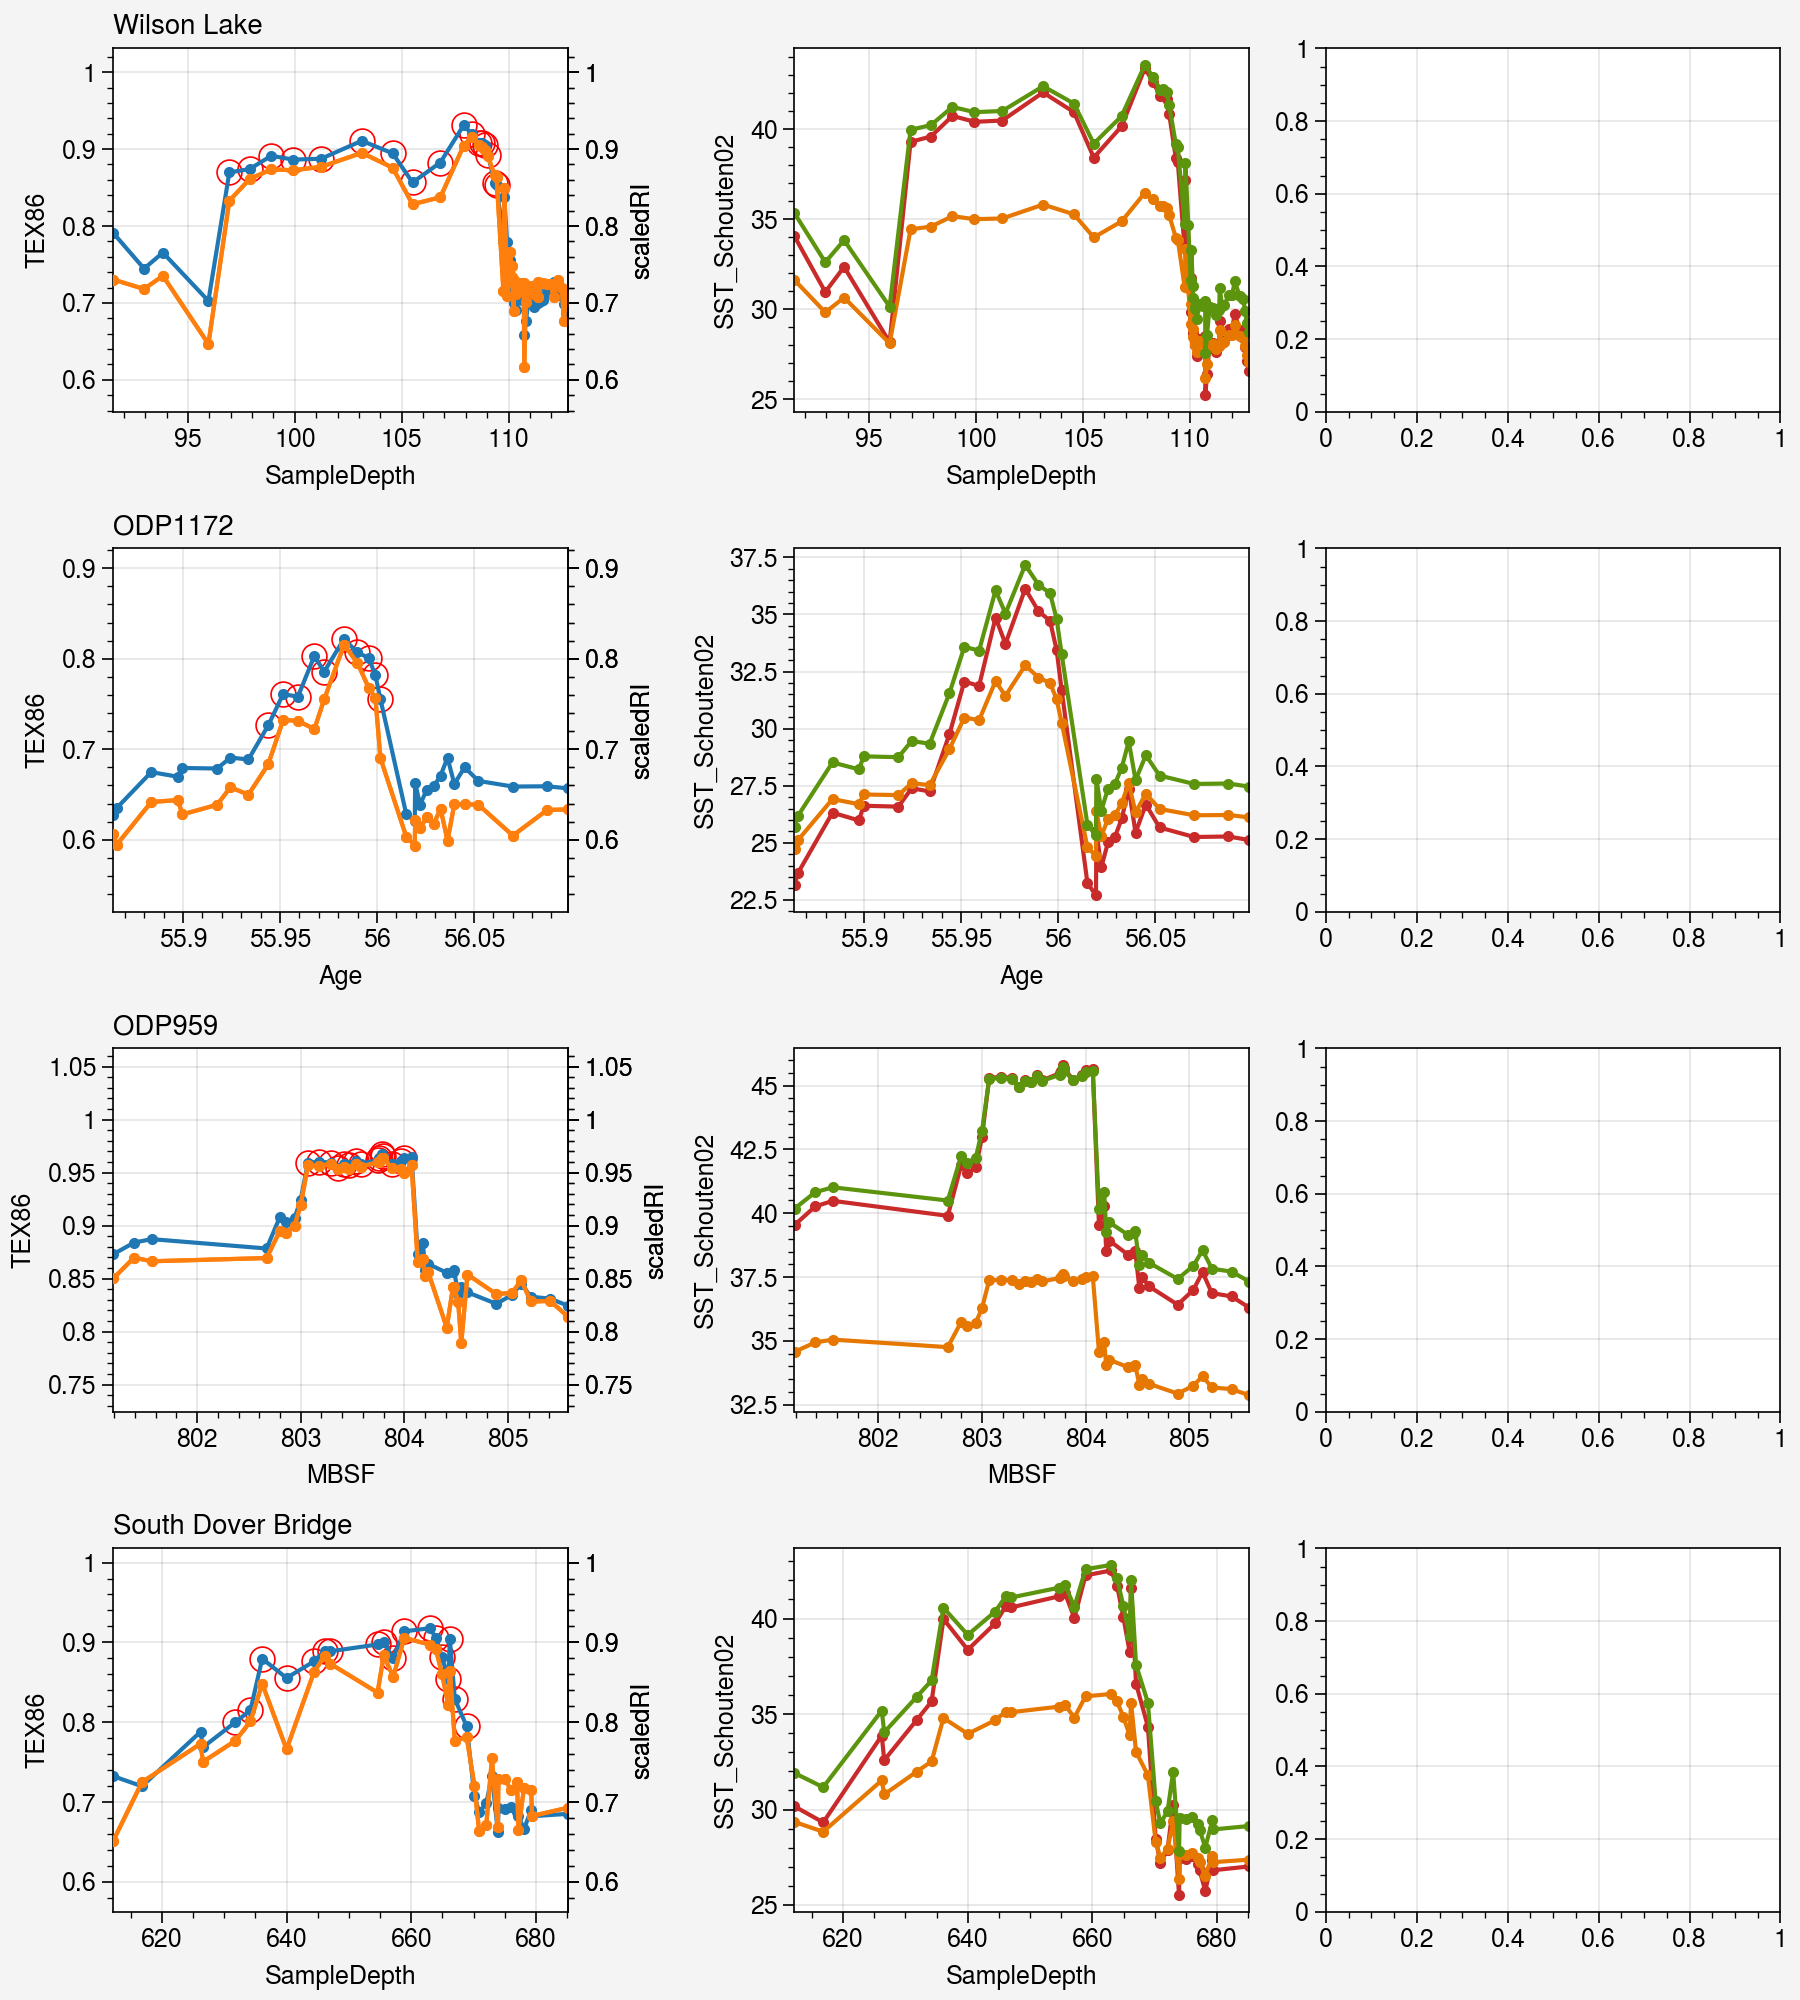

In [ ]:
fig, axs = plot.subplots(width=9,nrows=len(site_names_list),ncols=3, height=10, share=0)

for i, site_name in enumerate(site_names_list):
    sel_site_df = PhanTEX_PETM_df[PhanTEX_PETM_df['SiteName']==site_name]
    
    if site_name == 'ODP959':
        plot_data = sel_site_df.sort_values('MBSF').reset_index(drop=True)
        # Plot on primary axis
        axs[i,0].plot(plot_data['MBSF'], plot_data['TEX86'], m='.',
                      c='tab:blue', label=site_name)
        axs[i,0].format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        #### PETM highlights
        petm_data = plot_data[plot_data['PETM_interval']=='PETM']
        axs[i,0].scatter(petm_data['MBSF'], petm_data['TEX86'],
                         s=80, facecolor='none', edgecolor='red', label='PETM')
        
        # Create and store twin axis
        ax_twin = axs[i,0].twinx()
        ax_twin.plot(plot_data['MBSF'], plot_data['scaledRI'], m='.', label='', color='tab:orange')
        ax_twin.format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        # Plot predicted SSTs
        axs[i,1].plot(plot_data['MBSF'], plot_data['SST_Schouten02'], m='.', 
                      label='', color='red9')
        axs[i,1].plot(plot_data['MBSF'], plot_data['SST_Kim10'], m='.', 
                      label='', color='yellow9')
        axs[i,1].plot(plot_data['MBSF'], plot_data['SST_OBrien17'], m='.', 
                      label='', color='lime9')

    
    elif sel_site_df['SampleDepth'].isnull().all():
        plot_data = sel_site_df.sort_values('Age').reset_index(drop=True)
        
        # Plot on primary axis
        axs[i,0].plot(plot_data['Age'], plot_data['TEX86'], m='.',
                      c='tab:blue', label=site_name)
        axs[i,0].format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        
        #### PETM highlights
        petm_data = plot_data[plot_data['PETM_interval']=='PETM']
        axs[i,0].scatter(petm_data['Age'], petm_data['TEX86'],
                         s=80, facecolor='none', edgecolor='red', label='PETM')
        
        # Create and store twin axis
        ax_twin = axs[i,0].twinx()
        ax_twin.plot(plot_data['Age'], plot_data['scaledRI'], m='.', label='', color='tab:orange')
        ax_twin.format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        # Plot predicted SSTs
        axs[i,1].plot(plot_data['Age'], plot_data['SST_Schouten02'], m='.', 
                      label='', color='red9')
        axs[i,1].plot(plot_data['Age'], plot_data['SST_Kim10'], m='.', 
                      label='', color='yellow9')
        axs[i,1].plot(plot_data['Age'], plot_data['SST_OBrien17'], m='.', 
                      label='', color='lime9')
        

    else:
        plot_data = sel_site_df.sort_values('SampleDepth').reset_index(drop=True)
        
        # Plot on primary axis
        axs[i,0].plot(plot_data['SampleDepth'], plot_data['TEX86'], m='.', c='tab:blue', label=site_name)
        axs[i,0].format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        # PETM highlights
        petm_data = plot_data[plot_data['PETM_interval']=='PETM']
        axs[i,0].scatter(petm_data['SampleDepth'], petm_data['TEX86'],
                         s=80, facecolor='none', edgecolor='red', label='PETM')
        
        # Create and store twin axis
        ax_twin = axs[i,0].twinx()
        ax_twin.plot(plot_data['SampleDepth'], plot_data['scaledRI'], m='.', label='', color='tab:orange')
        ax_twin.format(ylim=(plot_data['TEX86'].min()-0.1, plot_data['TEX86'].max()+0.1))
        
        # Plot predicted SSTs
        axs[i,1].plot(plot_data['SampleDepth'], plot_data['SST_Schouten02'], m='.', 
                      label='', color='red9')
        axs[i,1].plot(plot_data['SampleDepth'], plot_data['SST_Kim10'], m='.', 
                      label='', color='yellow9')
        axs[i,1].plot(plot_data['SampleDepth'], plot_data['SST_OBrien17'], m='.', 
                      label='', color='lime9')

    axs[i,0].format(ltitle=site_name)

In [ ]:
grouped_site_df = PhanTEX_PETM_df.groupby('SiteName')
for site_name, sel_site_df in grouped_site_df:
    print(f"Site: {site_name}")
    
    search_tolerance = np.std(sel_site_df['TEX86'], ddof=1) * 2 if site_name != 'ODP959' else 0.25
    print (np.std(sel_site_df['TEX86'], ddof=1)*2)
    print("Search tolerance based on 2*SD of TEX86 values: ",f"{search_tolerance:.4f}")
    print(f"  Search tolerance: {search_tolerance:.4f}")
    pred_bsr_sst = bsr.predict_seatemp_analog(
            sel_site_df['TEX86'],
            prior_mean=30, 
            prior_std=20 if site_name != 'ODP959' else 25,
            temptype='sst',
            search_tol=search_tolerance ,
            nens=100).percentile([10,25,40,50,60,75,90])
    
    pred_bsr_subt = bsr.predict_seatemp_analog(
            sel_site_df['TEX86'],
            prior_mean=30, 
            prior_std=20 if site_name != 'ODP959' else 25,
            temptype='subt',
            search_tol=search_tolerance,
            nens=100).percentile([10,25,40,50,60,75,90])
    
    ### add predictions to dataframe
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_pred'] = pred_bsr_sst[:,3]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_subt_pred'] = pred_bsr_subt[:,3]
    
    ### collect P10, P25, P75, P90
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P10'] = pred_bsr_sst[:,0]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P25'] = pred_bsr_sst[:,1]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P40'] = pred_bsr_sst[:,2]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P60'] = pred_bsr_sst[:,4]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P75'] = pred_bsr_sst[:,5]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_SST_P90'] = pred_bsr_sst[:,6]
    
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_subt_P10'] = pred_bsr_subt[:,0]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_subt_P25'] = pred_bsr_subt[:,1]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_subt_P40'] = pred_bsr_subt[:,2]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_subt_P60'] = pred_bsr_subt[:,4]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_subt_P75'] = pred_bsr_subt[:,5]
    PhanTEX_PETM_df.loc[sel_site_df.index, 'BSR_subt_P90'] = pred_bsr_subt[:,6]
    
    
PhanTEX_PETM_df

Site: ODP1172
0.12102988235831143
Search tolerance based on 2*SD of TEX86 values:  0.1210
  Search tolerance: 0.1210


100%|██████████| 26/26 [00:00<00:00, 50.41it/s]


Site: ODP959
0.10639670472162806
Search tolerance based on 2*SD of TEX86 values:  0.2500
  Search tolerance: 0.2500


100%|██████████| 17/17 [00:00<00:00, 50.86it/s]


Site: South Dover Bridge
0.18404137894050768
Search tolerance based on 2*SD of TEX86 values:  0.1840
  Search tolerance: 0.1840


100%|██████████| 24/24 [00:00<00:00, 52.92it/s]


Site: Wilson Lake
0.1749124801177451
Search tolerance based on 2*SD of TEX86 values:  0.1749
  Search tolerance: 0.1749


100%|██████████| 24/24 [00:00<00:00, 44.10it/s]


,SampleID,SiteName,SiteHole,MBSF,MCD,SampleDepth,Formation,Country,ContinentOcean,ModLat,...,BSR_SST_P40,BSR_SST_P60,BSR_SST_P75,BSR_SST_P90,BSR_subt_P10,BSR_subt_P25,BSR_subt_P40,BSR_subt_P60,BSR_subt_P75,BSR_subt_P90
0,NaN,ODP1172,D,611.000,NaN,NaN,NaN,NaN,so,-43.96,...,23.156722,24.904697,26.580705,29.009410,15.938594,18.135044,19.715314,21.508493,23.289908,25.764162
1,NaN,ODP1172,D,611.010,NaN,NaN,NaN,NaN,so,-43.96,...,23.566507,25.366104,26.824620,29.282427,16.191241,18.457806,20.065292,22.109343,23.840399,26.306400
2,NaN,ODP1172,D,611.115,NaN,NaN,NaN,NaN,so,-43.96,...,26.085745,27.895211,29.664206,32.205253,19.252332,21.395992,22.947467,24.910875,26.772428,29.535172
3,NaN,ODP1172,D,611.195,NaN,NaN,NaN,NaN,so,-43.96,...,25.744204,27.658492,29.350997,31.843190,18.867089,20.942132,22.562422,24.720503,26.413073,28.815936
4,NaN,ODP1172,D,611.210,NaN,NaN,NaN,NaN,so,-43.96,...,26.318210,28.259026,29.828831,32.850078,19.291867,21.496505,23.226228,25.315038,27.208008,29.889374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,NaN,South Dover Bridge,NaN,NaN,NaN,677.20,NaN,United States of America,na,38.70,...,26.171350,28.123511,29.702205,32.551648,18.764375,21.332765,23.056338,25.179248,26.966677,29.898412
156,NaN,South Dover Bridge,NaN,NaN,NaN,678.10,NaN,United States of America,na,38.70,...,24.968900,26.935303,28.629075,31.135934,17.668106,20.339625,22.128116,24.167725,26.029059,28.706845
157,NaN,South Dover Bridge,NaN,NaN,NaN,679.25,NaN,United States of America,na,38.70,...,26.535948,28.503892,30.231752,33.014610,19.259012,21.859596,23.571924,25.650652,27.459788,30.180820
158,NaN,South Dover Bridge,NaN,NaN,NaN,679.40,NaN,United States of America,na,38.70,...,26.256736,28.076671,29.795468,32.439508,18.647116,21.281375,22.994743,25.286049,27.015450,29.732192


In [ ]:
# try:
#     multivar_post_ds.close()
#     multivar_post_ds2.close()
# except:
#     pass
# fwd_post = "gen_logi_fixed_hier_crtp_univ_priorApprox_SST_020526"
# PhanTEX_PETM_df['pred_SST_TEXAS_Tonly'] = predict_T_from_RI(
#     scaledRI=PhanTEX_PETM_df['scaledRI'].astype(float).tolist(),
#     prior_mu_t = 20.0,
#     prior_sigma_t = 6,
#     fwd_posterior_name=fwd_post,
#     site_name='PETM_sites',
#     save_results=True,

#     temptype='sst',
# )["p50"]

# ########################
# fwd_post = "gen_logi_fixed_hier_crtp_multiv_priorApprox_SST_gdgt23ratio_020526"
# PhanTEX_PETM_df['pred_SST_TEXAS_Tg23r'] = predict_T_from_RI(
#     scaledRI=PhanTEX_PETM_df['scaledRI'].astype(float).tolist(),
#     prior_mu_t = 20.0,
#     prior_sigma_t = 6,
#     fwd_posterior_name=fwd_post,
#     predictors={
#         'gdgt23ratio':PhanTEX_PETM_df['gdgt23ratio'].values,
#     },
#     site_name='PETM_sites',
#     save_results=True,

#     temptype='sst',
# )["p50"]

# fwd_post = "gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT_020526"
# PhanTEX_PETM_df['pred_thermoT_TEXAS_Tonly'] = predict_T_from_RI(
#     scaledRI=PhanTEX_PETM_df['scaledRI'].astype(float).tolist(),
#     prior_mu_t = 20.0,
#     prior_sigma_t = 6,
#     fwd_posterior_name=fwd_post,
#     site_name='PETM_sites',
#     save_results=True,

#     temptype='thermoT',
# )["p50"]

# ########################
# fwd_post = "gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_020526"
# PhanTEX_PETM_df['pred_thermoT_TEXAS_Tg23r'] = predict_T_from_RI(
#     scaledRI=PhanTEX_PETM_df['scaledRI'].astype(float).tolist(),
#     prior_mu_t = 20.0,
#     prior_sigma_t = 6,
#     fwd_posterior_name=fwd_post,
#     predictors={
#         'gdgt23ratio':PhanTEX_PETM_df['gdgt23ratio'].values,
#     },
#     site_name='PETM_sites',
#     save_results=True,

#     temptype='thermoT',
# )["p50"]

In [ ]:
fpath = f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache/'
fname = "PETM_sites_invT_gen_logi_fixed_univ_unconstrained_sst_direct.nc"

multivar_post_ds = xr.open_dataset(os.path.join(fpath,fname))

PhanTEX_PETM_df['pred_SST_TEXAS_Tonly_p10'] = multivar_post_ds.sel(quantile=0.10).t_est.values
PhanTEX_PETM_df['pred_SST_TEXAS_Tonly_p16'] = multivar_post_ds.sel(quantile=0.16).t_est.values
PhanTEX_PETM_df['pred_SST_TEXAS_Tonly_p25'] = multivar_post_ds.sel(quantile=0.25).t_est.values
PhanTEX_PETM_df['pred_SST_TEXAS_Tonly_p40'] = multivar_post_ds.sel(quantile=0.40).t_est.values
PhanTEX_PETM_df['pred_SST_TEXAS_Tonly_p50'] = multivar_post_ds.sel(quantile=0.50).t_est.values
PhanTEX_PETM_df['pred_SST_TEXAS_Tonly_p60'] = multivar_post_ds.sel(quantile=0.60).t_est.values
PhanTEX_PETM_df['pred_SST_TEXAS_Tonly_p75'] = multivar_post_ds.sel(quantile=0.75).t_est.values
PhanTEX_PETM_df['pred_SST_TEXAS_Tonly_p84'] = multivar_post_ds.sel(quantile=0.84).t_est.values
PhanTEX_PETM_df['pred_SST_TEXAS_Tonly_p90'] = multivar_post_ds.sel(quantile=0.90).t_est.values

fpath = f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache/'
fname = "PETM_sites_invT_gen_logi_fixed_multiv_unconstrained_sst_gdgt23ratio_direct.nc"

multivar_post_ds2 = xr.open_dataset(os.path.join(fpath,fname))
PhanTEX_PETM_df['pred_SST_TEXAS_Tg23r_p10'] = multivar_post_ds2.sel(quantile=0.10).t_est.values
PhanTEX_PETM_df['pred_SST_TEXAS_Tg23r_p16'] = multivar_post_ds2.sel(quantile=0.16).t_est.values
PhanTEX_PETM_df['pred_SST_TEXAS_Tg23r_p25'] = multivar_post_ds2.sel(quantile=0.25).t_est.values
PhanTEX_PETM_df['pred_SST_TEXAS_Tg23r_p40'] = multivar_post_ds2.sel(quantile=0.40).t_est.values
PhanTEX_PETM_df['pred_SST_TEXAS_Tg23r_p50'] = multivar_post_ds2.sel(quantile=0.50).t_est.values
PhanTEX_PETM_df['pred_SST_TEXAS_Tg23r_p60'] = multivar_post_ds2.sel(quantile=0.60).t_est.values
PhanTEX_PETM_df['pred_SST_TEXAS_Tg23r_p75'] = multivar_post_ds2.sel(quantile=0.75).t_est.values
PhanTEX_PETM_df['pred_SST_TEXAS_Tg23r_p84'] = multivar_post_ds2.sel(quantile=0.84).t_est.values
PhanTEX_PETM_df['pred_SST_TEXAS_Tg23r_p90'] = multivar_post_ds2.sel(quantile=0.90).t_est.values

fpath = f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache/'
fname = "PETM_sites_invT_gen_logi_fixed_univ_unconstrained_thermoT_direct.nc"

multivar_post_ds3 = xr.open_dataset(os.path.join(fpath,fname))
PhanTEX_PETM_df['pred_thermoT_TEXAS_Tonly_p10'] = multivar_post_ds3.sel(quantile=0.10).t_est.values
PhanTEX_PETM_df['pred_thermoT_TEXAS_Tonly_p16'] = multivar_post_ds3.sel(quantile=0.16).t_est.values
PhanTEX_PETM_df['pred_thermoT_TEXAS_Tonly_p25'] = multivar_post_ds3.sel(quantile=0.25).t_est.values
PhanTEX_PETM_df['pred_thermoT_TEXAS_Tonly_p40'] = multivar_post_ds3.sel(quantile=0.40).t_est.values
PhanTEX_PETM_df['pred_thermoT_TEXAS_Tonly_p50'] = multivar_post_ds3.sel(quantile=0.50).t_est.values
PhanTEX_PETM_df['pred_thermoT_TEXAS_Tonly_p60'] = multivar_post_ds3.sel(quantile=0.60).t_est.values
PhanTEX_PETM_df['pred_thermoT_TEXAS_Tonly_p75'] = multivar_post_ds3.sel(quantile=0.75).t_est.values
PhanTEX_PETM_df['pred_thermoT_TEXAS_Tonly_p84'] = multivar_post_ds3.sel(quantile=0.84).t_est.values
PhanTEX_PETM_df['pred_thermoT_TEXAS_Tonly_p90'] = multivar_post_ds3.sel(quantile=0.90).t_est.values

fpath = f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache/'
fname = "PETM_sites_invT_gen_logi_fixed_multiv_unconstrained_thermoT_gdgt23ratio_direct.nc"

multivar_post_ds4 = xr.open_dataset(os.path.join(fpath,fname))
PhanTEX_PETM_df['pred_thermoT_TEXAS_Tg23r_p10'] = multivar_post_ds4.sel(quantile=0.10).t_est.values
PhanTEX_PETM_df['pred_thermoT_TEXAS_Tg23r_p16'] = multivar_post_ds3.sel(quantile=0.16).t_est.values
PhanTEX_PETM_df['pred_thermoT_TEXAS_Tg23r_p25'] = multivar_post_ds4.sel(quantile=0.25).t_est.values
PhanTEX_PETM_df['pred_thermoT_TEXAS_Tg23r_p40'] = multivar_post_ds4.sel(quantile=0.40).t_est.values
PhanTEX_PETM_df['pred_thermoT_TEXAS_Tg23r_p50'] = multivar_post_ds4.sel(quantile=0.50).t_est.values
PhanTEX_PETM_df['pred_thermoT_TEXAS_Tg23r_p60'] = multivar_post_ds4.sel(quantile=0.60).t_est.values
PhanTEX_PETM_df['pred_thermoT_TEXAS_Tg23r_p75'] = multivar_post_ds4.sel(quantile=0.75).t_est.values
PhanTEX_PETM_df['pred_thermoT_TEXAS_Tg23r_p84'] = multivar_post_ds3.sel(quantile=0.84).t_est.values
PhanTEX_PETM_df['pred_thermoT_TEXAS_Tg23r_p90'] = multivar_post_ds4.sel(quantile=0.90).t_est.values

In [ ]:
predT_model_list = ['SST_Schouten02', 'SST_Kim10', 'BSR_SST_pred', 'pred_SST_TEXAS_Tg23r_p50']
site_names = PhanTEX_PETM_df['SiteName'].unique()
diff_data = {}
diff_T_column_list = []


for i, site_name in enumerate(site_names):
    petm_idx = (PhanTEX_PETM_df['SiteName']==site_name) & (PhanTEX_PETM_df['PETM_interval']=='PETM')
    
    prePETM_idx = (PhanTEX_PETM_df['SiteName']==site_name) & (PhanTEX_PETM_df['PETM_interval']=='pre-PETM')
        
    for predT_model in predT_model_list:
        prePETM_median = PhanTEX_PETM_df.loc[prePETM_idx, predT_model].median()
        
        PhanTEX_PETM_df.loc[petm_idx, f'diffT_{predT_model}'] = PhanTEX_PETM_df.loc[petm_idx, predT_model] - prePETM_median
        
        if i == 0:
            diff_T_column_list.append(f'diffT_{predT_model}')
        
    

diff_data = pd.DataFrame(diff_data, index=[0])
feature = ['SiteName'] + diff_T_column_list
paleo_diffT_df = PhanTEX_PETM_df[PhanTEX_PETM_df['PETM_interval']=='PETM'][feature].copy().reset_index(drop=True)
paleo_diffT_df

,SiteName,diffT_SST_Schouten02,diffT_SST_Kim10,diffT_BSR_SST_pred,diffT_pred_SST_TEXAS_Tg23r_p50
0,ODP1172,4.483206,2.886249,4.397202,3.09730
1,ODP1172,6.791423,4.269633,6.548374,5.70055
2,ODP1172,6.600283,4.157492,6.273216,5.46895
3,ODP1172,9.590426,5.865076,9.519286,5.18385
4,ODP1172,8.441466,5.220498,8.209049,6.66080
5,ODP1172,10.854670,6.558533,10.427832,9.82850
6,ODP1172,9.875364,6.022788,9.487035,8.82095
7,ODP1172,9.445763,5.784684,9.052365,7.38570
8,ODP1172,8.169252,5.065711,7.854305,6.81725
9,ODP1172,6.412067,4.046651,6.197661,3.48530


In [ ]:
diffT_PETMDA_da = (PETMDA_ds_regridded['sst'].isel(nTime=0) - PETMDA_ds_regridded['sst'].isel(nTime=1))
diffT_PETMDA_da

<xarray.DataArray 'sst' (lat: 181, lon: 361)>
array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [6.55429488, 6.55420904, 6.55412688, ..., 6.5545155 , 6.55439822,
        6.55429488],
       [6.55925685, 6.55920673, 6.55915695, ..., 6.55935795, 6.55930726,
        6.55925685],
       [6.55525903, 6.55529453, 6.55532939, ..., 6.55518613, 6.55522289,
        6.55525903]])
Coordinates:
  * lat      (lat) float64 -89.5 -88.5 -87.5 -86.5 -85.5 ... 87.5 88.5 89.5 90.5
  * lon      (lon) float64 -179.5 -178.5 -177.5 -176.5 ... 178.5 179.5 180.5

In [ ]:
nonnan_idx = ~PhanTEX_PETM_df['paleolat'].isnull() & ~PhanTEX_PETM_df['paleolon'].isnull()
plot_data = PhanTEX_PETM_df[nonnan_idx].reset_index(drop=True)

Reference: Wilson Lake ['Zachos2006', 'Sluijs2007']
Reference: ODP959 ['Frieling2018']


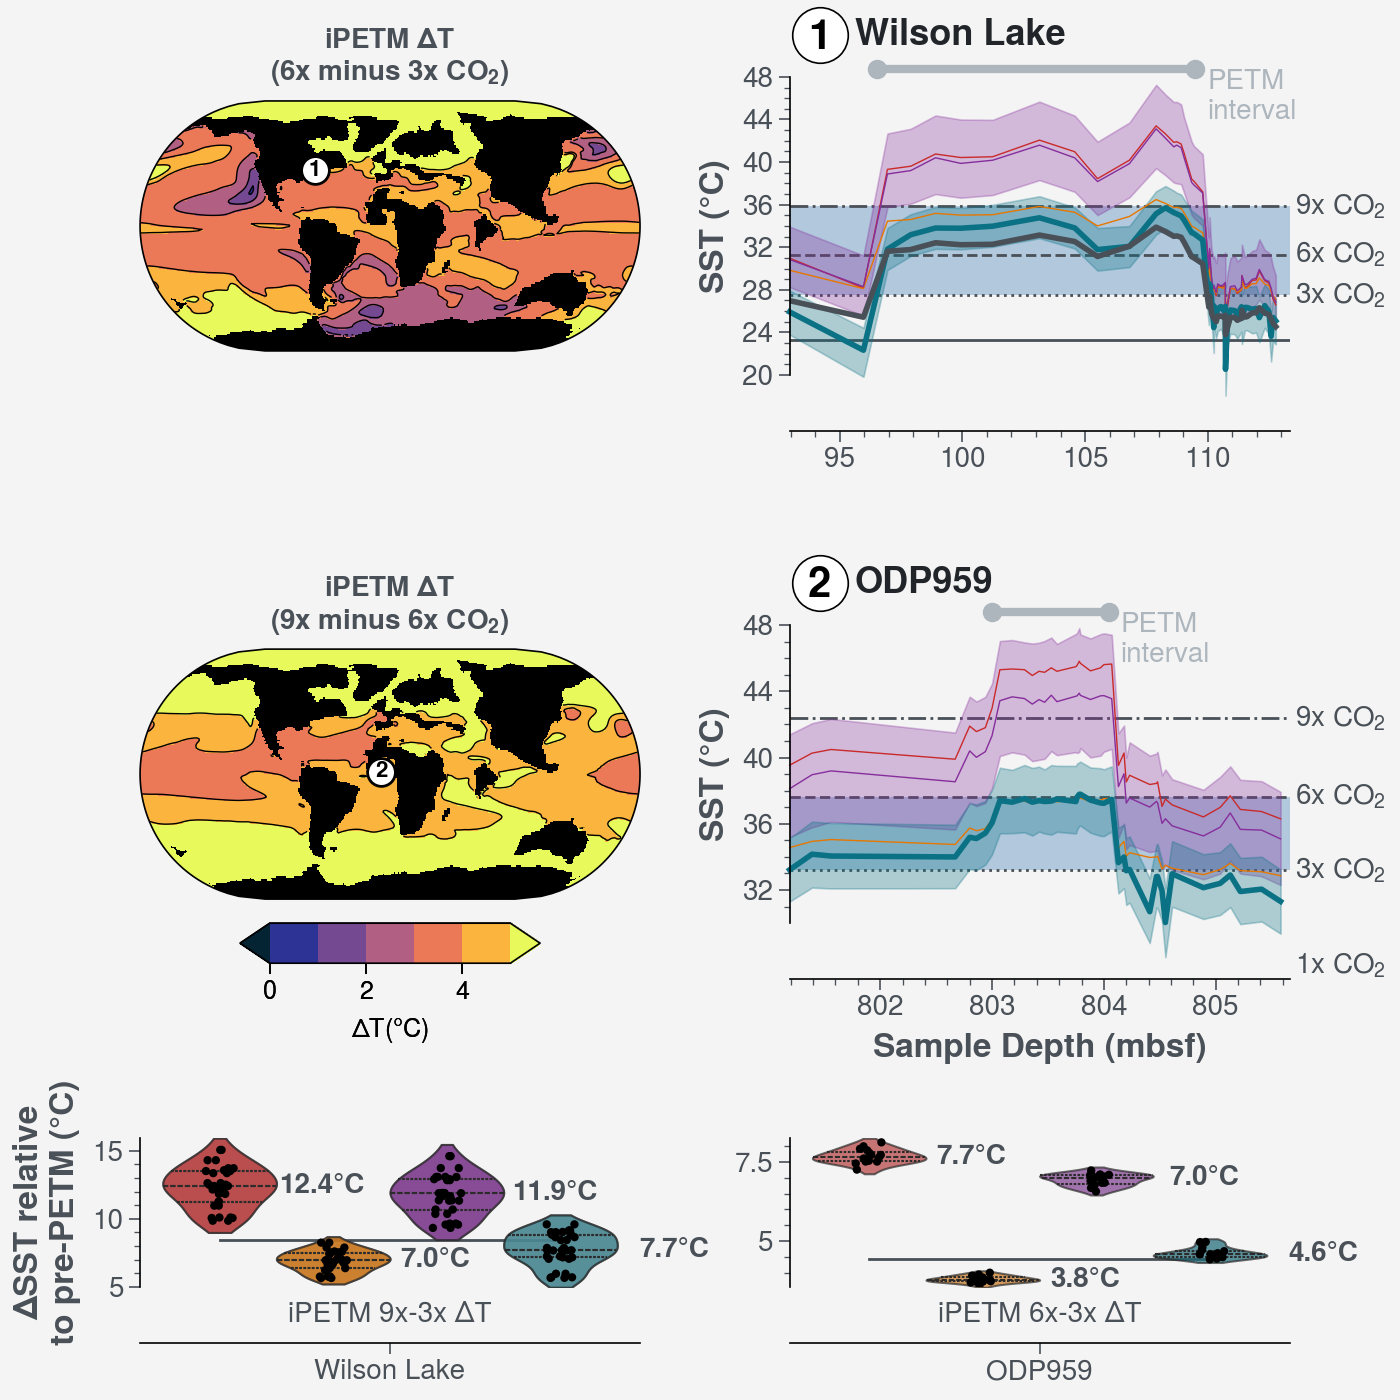

In [ ]:
plot_data = PhanTEX_PETM_df[PhanTEX_PETM_df['SiteName'].isin(['Wilson Lake', 'ODP959'])][
    PhanTEX_PETM_df['TEXRI_mahalDist_low23ratio_outliers_manual']==False].sort_values('SampleDepth').reset_index(drop=True)



fig, axs = plot.subplots(nrows=3,ncols=2,
                         proj={1:'eck3',3:'eck3'},
                         figsize=(7,7),share=0,
                         hspace=[10,7],
                         hratios=[1,1,0.5])

########### Left column plots
iPETM_ds_list = [(iPETM_06x_ds - iPETM_03x_ds), (iPETM_09x_ds - iPETM_06x_ds)]
for i, iPETM_ds in enumerate(iPETM_ds_list):
    ax = axs[i,0]
    ax.format(facecolor='k')
    plot_temp = iPETM_ds['TEMP'].squeeze('z_t').mean('time').values
    plot_lat = iPETM_ds['lat'].values
    plot_lon = iPETM_ds['lon'].values
    pcm = ax.pcolormesh(plot_lon, plot_lat, plot_temp, cmap='thermal', rasterized=True,
                        robust=True, levels=np.arange(0, 5.1, 1), vmin=0, vmax=5,
                        extend='both'
                        )
    ax.contour(plot_lon, plot_lat, plot_temp, levels=np.arange(0, 5.1, 1), colors='k', linewidths=0.5)
    if i == 1:
        ax.colorbar(pcm, label=r'$ \Delta T (°C)$', loc='bottom',shrink=0.6)

    text = r"iPETM $\Delta$T"+f"\n{[r'(6x minus 3x CO$_{2}$)',r'(9x minus 6x CO$_{2}$)'][i]}"
    ax.text(0.5, 1.05, text, transform=ax.transAxes, ha='center', va='bottom', 
            fontsize=10, fontweight='bold', color='gray7')

########### Right column
plot_data['SiteName'] = pd.Categorical(plot_data['SiteName'], categories=['Wilson Lake', 'ODP959'], ordered=True)
grouped = plot_data.groupby('SiteName')

temp_methods = ['SST_Schouten02','SST_Kim10','BSR_SST_pred', 'pred_SST_TEXAS_Tg23r_p50']
temp_T_range_dict = {
    'BSR_SST_pred': ('BSR_SST_P25', 'BSR_SST_P75'),
    'pred_SST_TEXAS_Tg23r_p50': ('pred_SST_TEXAS_Tg23r_p25', 'pred_SST_TEXAS_Tg23r_p75')
}
plot_colors = ['red9','yellow9','grape9','cyan9']
plot_styles = ['-','-','-','-']
labels = ['Schouten et al. (2002)','Kim et al. (2010)',
          'BSR SST Prediction','TEXAS (T only)','TEXAS (T + gdgt23ratio)'
          ]
### plot PETM range at the top edge of axis
PETM_interval_dict_sampleDepth = {
    'ODP959': (803,804.05),
    'Wilson Lake': (96.5, 109.5),
}

site_iPETM_temps = {}
for i, (site_name, group) in enumerate(grouped):
    ax = axs[i,1]
    
    ax.scatter(0.06, 1.14, marker='o', color='w', mec='k', markersize=400,   
            transform=ax.transAxes, clip_on=False, zorder=-1)
    ax.text(0.06, 1.13, i+1, 
            transform=ax.transAxes, 
            fontsize=15, fontweight='bold', 
            ha='center', va='center', color='k',)
    ax.text(0.13, 1.14, site_name, transform=ax.transAxes,
            fontsize=13, fontweight='bold',
            ha='left', va='center', color='gray9',)
    
    plot_group = group.sort_values('SampleDepth').reset_index(drop=True)
    
    for method, color, style, label in zip(temp_methods, plot_colors, plot_styles, labels):
        plot_x = plot_group['SampleDepth'] if plot_group['SampleDepth'].notnull().any() else plot_group['MBSF']
        nonnan_idx = plot_group[method].notnull() & plot_x.notnull()
        ax.plot(plot_x[nonnan_idx], plot_group[method][nonnan_idx], 
                lw=2 if "TEXAS" in method else 0.5,
                ls=style, color=color, label=label,
                clip_on=False)
        
        if (("BSR" in method) or ("TEXAS" in method)) and plot_group[method].notnull().any():
            lower_col, upper_col = temp_T_range_dict[method]
            ax.fill_between(plot_x[nonnan_idx], plot_group[lower_col][nonnan_idx], 
                            plot_group[upper_col][nonnan_idx], 
                            color=color, alpha=0.3, clip_on=False)
            
    if site_name == 'Wilson Lake':
        published_T = (group['TEX86'] - 0.016) / 0.027
        ax.plot(group['SampleDepth'], published_T, lw=2, color='gray7', label='published SST')
    
    iPETM_01x_temp = np.nan
    ii = 0
    while np.isnan(iPETM_01x_temp):
        iPETM_01x_temp = iPETM_01x_ds['TEMP'].squeeze('z_t').mean('time').sel(
            lat = plot_group['paleolat'].values[0] - ii,
            lon = plot_group['paleolon'].values[0] - ii,
            method='nearest'
        ).values
        ii += 1
    
    iPETM_03x_temp = np.nan
    ii = 0
    while np.isnan(iPETM_03x_temp):
        iPETM_03x_temp = iPETM_03x_ds['TEMP'].squeeze('z_t').mean('time').sel(
            lat = plot_group['paleolat'].values[0] - ii,
            lon = plot_group['paleolon'].values[0] - ii,
            method='nearest'
        ).values
        ii += 1
        
    iPETM_06x_temp = np.nan
    ii = 0
    while np.isnan(iPETM_06x_temp):
        iPETM_06x_temp = iPETM_06x_ds['TEMP'].squeeze('z_t').mean('time').sel(
            lat = plot_group['paleolat'].values[0] - ii,
            lon = plot_group['paleolon'].values[0] - ii,
            method='nearest'
        ).values
        ii += 1
    
    iPETM_09x_temp = np.nan
    ii = 0
    while np.isnan(iPETM_09x_temp):
        iPETM_09x_temp = iPETM_09x_ds['TEMP'].squeeze('z_t').mean('time').sel(
            lat = plot_group['paleolat'].values[0] - ii,
            lon = plot_group['paleolon'].values[0] - ii,
            method='nearest'
        ).values
        ii += 1
    
    ax.axhline(iPETM_01x_temp, color='gray7', lw=1, label='iPETM 1x', zorder=0)
    ax.axhline(iPETM_03x_temp, color='gray7', lw=1, ls=':', label='iPETM 3x', zorder=0)
    ax.axhline(iPETM_06x_temp, color='gray7', lw=1, ls='--', label='iPETM 6x', zorder=0)
    ax.axhline(iPETM_09x_temp, color='gray7', lw=1, ls='-.', label='iPETM 9x', zorder=0)
    
    site_iPETM_temps[site_name] = [iPETM_01x_temp, iPETM_03x_temp, iPETM_06x_temp, iPETM_09x_temp]
    
    ###
    text_list = [r"1x CO$_2$",r"3x CO$_2$", r"6x CO$_2$", r"9x CO$_2$"]
    for j, iPETM_temp in enumerate([iPETM_01x_temp, iPETM_03x_temp, iPETM_06x_temp, iPETM_09x_temp]):
        
        if i == 0 and j == 0:
            continue
        else:
            ax.text(1.01, iPETM_temp, text_list[j], transform=ax.get_yaxis_transform(), 
                    va='center', ha='left', fontsize=10,
                    color='gray7')
            
    y_top_edge = ax.get_ylim()[1]
    petm_start, petm_end = PETM_interval_dict_sampleDepth[site_name]
    ax.plot([petm_start, petm_end], [y_top_edge, y_top_edge],
            m='o', color='gray5', lw=3, label='PETM interval', zorder=5,
            clip_on=False)
    ax.text(petm_end+0.5 if site_name == 'Wilson Lake' else petm_end+0.1, 
            y_top_edge, 'PETM\ninterval', va='top', ha='left', 
            fontsize=10, color='gray5',clip_on=False)
    
    ax.format(
        xlim=(ax.get_xlim()[0], 
              ax.get_xlim()[1]*1.005 if site_name == 'Wilson Lake' else ax.get_xlim()[1]*1.0001
              )
    )
    
    

ax = axs[2,0]

plot_data = paleo_diffT_df[paleo_diffT_df['SiteName'].isin(['Wilson Lake'])]
sns.violinplot(
    data=plot_data.melt(id_vars=['SiteName'], value_vars=diff_T_column_list, var_name='variable', value_name='value'),
    x='SiteName',
    y='value',
    hue='variable',
    palette=['red9', 'yellow9', 'grape9', 'gray2', 'gray2'],
    split=False,
    inner='quartile',
    ax=ax,  
    density_norm='width',
    cut=1,
    legend=False,
    alpha=0.7
)

sns.stripplot(
    data=plot_data.melt(id_vars=['SiteName'], value_vars=diff_T_column_list, var_name='variable', value_name='value'),
    x='SiteName',
    y='value',
    hue='variable',  # Keep this to align with violins
    palette=['black'] * 5,  # All black colors
    dodge=True,  # Important: align with the dodged violins
    size=3,  # Adjust point size
    # alpha=0.6,  # Adjust transparency
    ax=ax,
    legend=False  # Don't show legend for stripplot
)

ax = axs[2,0]

plot_data = paleo_diffT_df[paleo_diffT_df['SiteName'].isin(['Wilson Lake'])]
sns.violinplot(
    data=plot_data.melt(id_vars=['SiteName'], value_vars=diff_T_column_list, var_name='variable', value_name='value'),
    x='SiteName',
    y='value',
    hue='variable',
    palette=['red9', 'yellow9', 'grape9', 'cyan9'],
    split=False,
    inner='quartile',
    ax=ax,  
    density_norm='width',
    cut=1,
    legend=False,
    alpha=0.7
)

sns.stripplot(
    data=plot_data.melt(id_vars=['SiteName'], value_vars=diff_T_column_list, var_name='variable', value_name='value'),
    x='SiteName',
    y='value',
    hue='variable',  # Keep this to align with violins
    palette=['black'] * 5,  # All black colors
    dodge=True,  # Important: align with the dodged violins
    size=3,  # Adjust point size
    # alpha=0.6,  # Adjust transparency
    ax=ax,
    legend=False  # Don't show legend for stripplot
)

ax = axs[2,1]
plot_data = paleo_diffT_df[paleo_diffT_df['SiteName'].isin(['ODP959'])]
sns.violinplot(
    data=plot_data.melt(id_vars=['SiteName'], value_vars=diff_T_column_list, var_name='variable', value_name='value'),
    x='SiteName',
    y='value',
    hue='variable',
    palette=['red9', 'yellow9', 'grape9', 'cyan9'],
    split=False,
    inner='quartile',
    ax=ax,  
    density_norm='width',
    cut=1,
    legend=False,
    alpha=0.7
)

sns.stripplot(
    data=plot_data.melt(id_vars=['SiteName'], value_vars=diff_T_column_list, var_name='variable', value_name='value'),
    x='SiteName',
    y='value',
    hue='variable',  # Keep this to align with violins
    palette=['black'] * 5,  # All black colors
    dodge=True,  # Important: align with the dodged violins
    size=3,  # Adjust point size
    # alpha=0.6,  # Adjust transparency
    ax=ax,
    legend=False  # Don't show legend for stripplot
)

### iPETM diffT

iPETM_diffT_0309_WilsonLake = site_iPETM_temps['Wilson Lake'][3] - site_iPETM_temps['Wilson Lake'][1]
axs[2,0].plot([-0.3,0.3], [iPETM_diffT_0309_WilsonLake, iPETM_diffT_0309_WilsonLake], color='gray7', lw=1, label='iPETM 9x ΔT', zorder=0)
axs[2,0].text(0.5, -0.1, r"iPETM 9x-3x ΔT", 
              va='top', ha='center', 
              fontsize=10, color='gray7',
              transform=axs[2,0].transAxes)

iPETM_diffT_0306_ODP959 = site_iPETM_temps['ODP959'][2] - site_iPETM_temps['ODP959'][1]
axs[2,1].plot([-0.3,0.3], [iPETM_diffT_0306_ODP959, iPETM_diffT_0306_ODP959], color='gray7', lw=1, label='iPETM 6x ΔT', zorder=0)
axs[2,1].text(0.5, -0.1, r"iPETM 6x-3x ΔT", 
              va='top', ha='center', 
              fontsize=10, color='gray7',
              transform=axs[2,1].transAxes)

### label median values of violins
for i, site_name in enumerate(['Wilson Lake','ODP959']):
    site_diffT_data = paleo_diffT_df[paleo_diffT_df['SiteName']==site_name][diff_T_column_list]
    for j, diff_T_col in enumerate(diff_T_column_list):
        median_value = site_diffT_data[diff_T_col].median()
        axs[2,i].text([-0.12,0.08,0.29,0.5][j], 
                      median_value, 
                      f"{median_value:.1f}°C", 
                va='center', ha='center', fontsize=10, color='gray7',
                fontweight='bold')



### shade in axs[0,1] between iPETM 3x and 6x
ax = axs[1,1]
iPETM_03x_temp = site_iPETM_temps['ODP959'][1]
iPETM_06x_temp = site_iPETM_temps['ODP959'][2]
ax.fill_between([ax.get_xlim()[0], ax.get_xlim()[1]], 
                iPETM_03x_temp, iPETM_06x_temp, 
                color='blue9', alpha=0.3, lw=0, 
                label='iPETM 3x-6x ΔT', zorder=0)


### shade in axs[1,1] between iPETM 3x and 9x
ax = axs[0,1]
iPETM_03x_temp = site_iPETM_temps['Wilson Lake'][1]
iPETM_09x_temp = site_iPETM_temps['Wilson Lake'][3]
ax.fill_between([ax.get_xlim()[0], ax.get_xlim()[1]], 
                iPETM_03x_temp, iPETM_09x_temp, 
                color='blue9', alpha=0.3, lw=0, 
                label='iPETM 3x-9x ΔT', zorder=0)
        


ylabels_axs_dict = {
    2: 'SST (°C)',
    4: 'SST (°C)',
    5: 'ΔSST relative\nto pre-PETM (°C)',
    6: '',
}

xlabels_axs_dict = {
    2: '',
    4: 'Sample Depth (mbsf)',
    5: '',
    6: '',
}

for iax, ax in enumerate(axs, start=1):
    if iax in ylabels_axs_dict:
        ax.set(ylabel=ylabels_axs_dict[iax])
    if iax in xlabels_axs_dict:
        ax.set(xlabel=xlabels_axs_dict[iax])

axs.format(
    grid=False,
    labelsize=12,labelweight='bold',labelcolor='gray7',
    xticklabelsize=10, yticklabelsize=10,
    xtickcolor='gray7', ytickcolor='gray7',
    xticklabelcolor='gray7', yticklabelcolor='gray7',
)

for ax in axs[:,1]:
    ax.set_facecolor('none')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_position(('outward', 20))

axs[2,0].set_facecolor('none')
axs[2,0].spines['right'].set_visible(False)
axs[2,0].spines['top'].set_visible(False)
axs[2,0].spines['bottom'].set_position(('outward', 20))



ylim_list = [(20,48),(30,48)]
for i, ylim in enumerate(ylim_list):
    axs[i,1].format(ylim=ylim,
                    yticks=np.arange(12, ylim[1]+1, 4))

#### plot paleolocations
site_name_list = ['Wilson Lake', 'ODP959']
for i, site_name in enumerate(site_name_list):
    ax = axs[i,0]
    paleolat = PhanTEX_df[PhanTEX_df['SiteName']==site_name]['paleolat'].values[0]
    paleolon = PhanTEX_df[PhanTEX_df['SiteName']==site_name]['paleolon'].values[0]
    ax.plot(paleolon, paleolat, m='o', c='w', mec='k', markersize=10)
    ax.text(paleolon, paleolat, i+1, va='center', ha='center', fontsize=8, color='k', fontweight='bold',
            transform=ccrs.PlateCarree())
    
    sites_ = [PhanTEX_PETM_df[PhanTEX_PETM_df['SiteName']==site_name]['pubYear'].unique()[i] for i in range(len(PhanTEX_PETM_df[PhanTEX_PETM_df['SiteName']==site_name]['pubYear'].unique()))]
    print(r"Reference:", f"{site_name} {sites_}")
    
plot.rc['abc'] = False

fpath = f'{local_github_path}/figures/manuscript/finalized/main-text'
fname = "Fig13_PETM_proxymodel_comparisons.pdf"
fig.savefig(os.path.join(fpath,fname), dpi=300, bbox_inches='tight')

In [ ]:
combined_df_raw['SST'].max()

In [ ]:
plot_data.melt(id_vars=['SiteName'], value_vars=diff_T_column_list, var_name='variable', value_name='value')

In [ ]:
fpath = f'{local_github_path}/data/spreadsheets/published_data/'
fname = 'Babila2022_MgCa_SDB_PETM.xlsx'

SDB_MgCa_df = pd.read_excel(os.path.join(fpath,fname))
SDB_MgCa_df